# Problem Statement

## Background
In large-scale biopharmaceutical fermentation processes, maintaining optimal conditions is essential for achieving high product yield and consistent quality. However, direct measurement of critical quality variables during operation remains a significant challenge.

## Problem Description
Key process variables—such as penicillin concentration, phenylacetic acid (PAA), biomass, nitrogen, and viscosity—are typically measured using offline laboratory assays. These measurements are infrequent (approximately every 12 hours) and involve significant delays (around 4 hours), resulting in extended periods where the actual state of the process is unknown.

This creates operational blind spots during which the system may drift from optimal conditions. Issues such as substrate depletion, imbalance in precursor concentration, or oxygen limitation can arise without immediate detection. Due to the absence of real-time feedback, operators are unable to take timely corrective actions.

## Impact
The lack of continuous monitoring leads to reduced process efficiency, variability in product quality, and increased risk of batch failure. In large-scale systems, even minor deviations can significantly affect overall production yield, making this limitation a critical bottleneck in process optimization.

## Need for Solution
There is a need for a method that can provide continuous estimates of critical quality variables using readily available process data. A machine learning-based soft sensor can address this by predicting these variables in real time from indirect measurements such as temperature, pH, gas composition, and other on-line signals. This would enable proactive monitoring, improved control, and more reliable production outcomes.

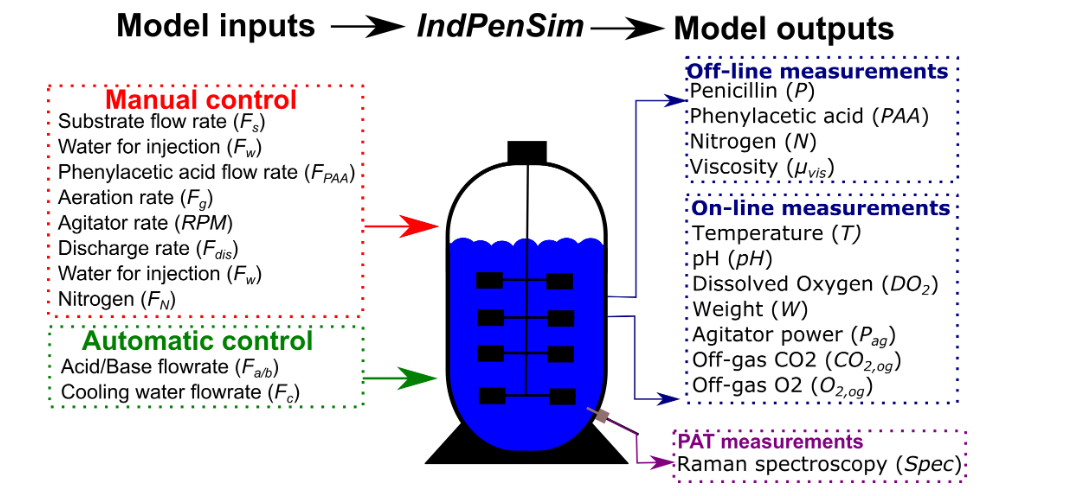

# 1) Loading Dataset

## Dataset Description

The dataset is downloaded from: http://www.industrialpenicillinsimulation.com/

The dataset represents a **time-series industrial process** collected from a large-scale biopharmaceutical fermentation system. Data is recorded at a fixed interval of approximately **every 12 minutes (0.2 hours)**.

Each experiment corresponds to a **batch (complete production run)**.  
- Each batch runs for a **different duration** (typically ~230 hours)  
- Therefore, each batch contains a **different number of time points (rows)**  
- Each row represents a **snapshot of the process at a given time**

The dataset consists of **100 batches**, categorized as follows:

- **Batches 1–30**: Controlled using a recipe-driven approach  
- **Batches 31–60**: Controlled manually by operators  
- **Batches 61–90**: Controlled using an Advanced Process Control (APC) system with Raman spectroscopy  
- **Batches 91–100**: Contain faults resulting in process deviations  


In [7]:
import pandas as pd

df_statistics = pd.read_csv('/kaggle/input/datasets/nishantmalhotra8009/bm616-data/Mendeley_data/100_Batches_IndPenSim_Statistics.csv')
df = pd.read_csv('/kaggle/input/datasets/nishantmalhotra8009/bm616-data/Mendeley_data/100_Batches_IndPenSim_V3.csv')

In [8]:
df.columns

Index(['Time (h)', 'Aeration rate(Fg:L/h)', 'Agitator RPM(RPM:RPM)',
       'Sugar feed rate(Fs:L/h)', 'Acid flow rate(Fa:L/h)',
       'Base flow rate(Fb:L/h)', 'Heating/cooling water flow rate(Fc:L/h)',
       'Heating water flow rate(Fh:L/h)',
       'Water for injection/dilution(Fw:L/h)',
       'Air head pressure(pressure:bar)',
       ...
       '210', '209', '208', '207', '206', '205', '204', '203', '202', '201'],
      dtype='object', length=2239)

In [9]:
process_cols = [col for col in df.columns if not col.isdigit()]

for col in process_cols:
    print(col)

Time (h)
Aeration rate(Fg:L/h)
Agitator RPM(RPM:RPM)
Sugar feed rate(Fs:L/h)
Acid flow rate(Fa:L/h)
Base flow rate(Fb:L/h)
Heating/cooling water flow rate(Fc:L/h)
Heating water flow rate(Fh:L/h)
Water for injection/dilution(Fw:L/h)
Air head pressure(pressure:bar)
Dumped broth flow(Fremoved:L/h)
Substrate concentration(S:g/L)
Dissolved oxygen concentration(DO2:mg/L)
Penicillin concentration(P:g/L)
Vessel Volume(V:L)
Vessel Weight(Wt:Kg)
pH(pH:pH)
Temperature(T:K)
Generated heat(Q:kJ)
carbon dioxide percent in off-gas(CO2outgas:%)
PAA flow(Fpaa:PAA flow (L/h))
PAA concentration offline(PAA_offline:PAA (g L^{-1}))
Oil flow(Foil:L/hr)
NH_3 concentration off-line(NH3_offline:NH3 (g L^{-1}))
Oxygen Uptake Rate(OUR:(g min^{-1}))
Oxygen in percent in off-gas(O2:O2  (%))
Offline Penicillin concentration(P_offline:P(g L^{-1}))
Offline Biomass concentratio(X_offline:X(g L^{-1}))
Carbon evolution rate(CER:g/h)
Ammonia shots(NH3_shots:kgs)
Viscosity(Viscosity_offline:centPoise)
Fault reference(Faul

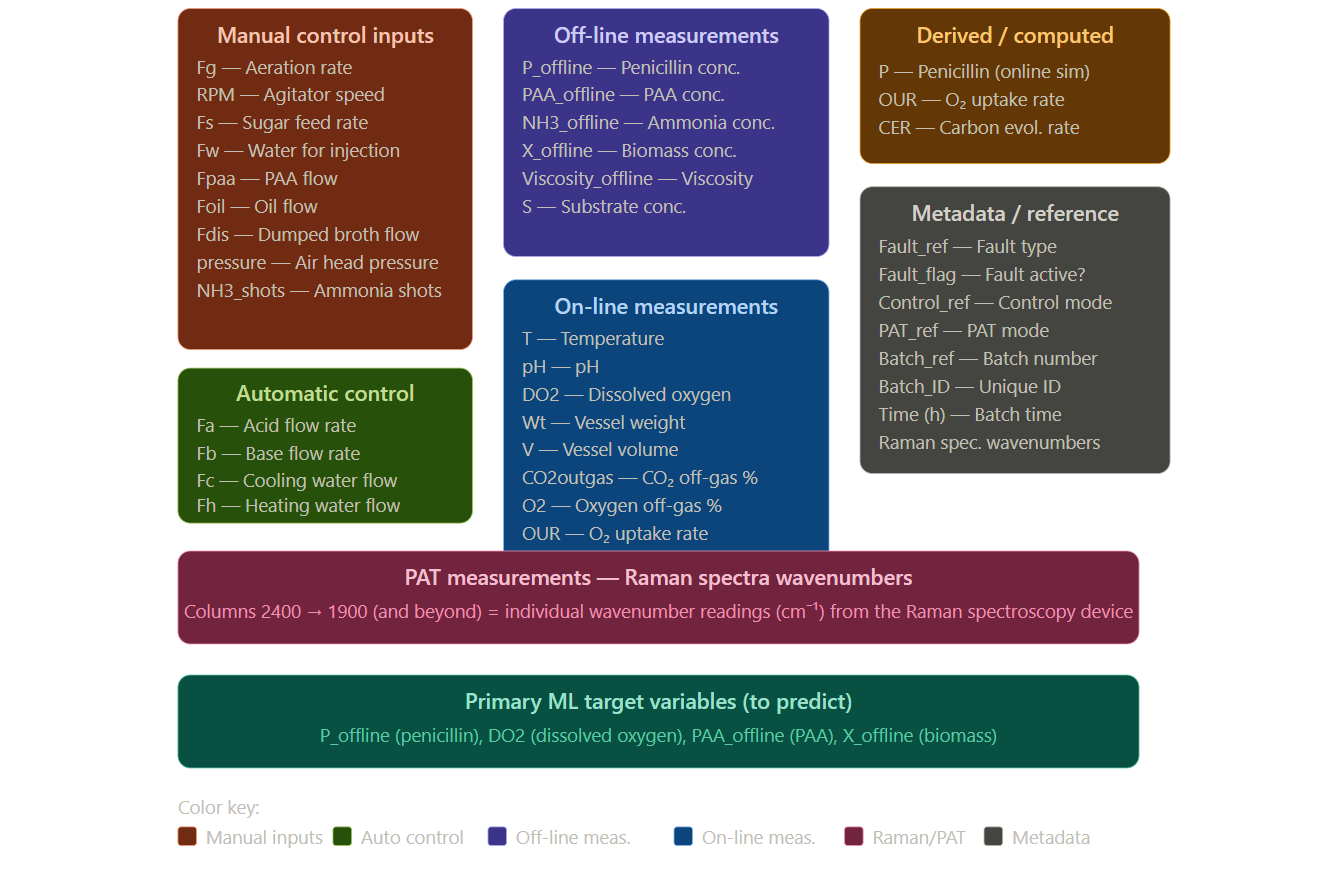

# 2) Exploratory Data Analysis
## A) Metadata 
 ### i) Analysis 

In [10]:
metadata_cols = [
    'Time (h)',
    'Fault reference(Fault_ref:Fault ref)', 
    '0 - Recipe driven 1 - Operator controlled(Control_ref:Control ref)', 
    '2-PAT control(PAT_ref:PAT ref)', 
    'Batch reference(Batch_ref:Batch ref)', 
    'Batch ID', 'Fault flag', 
    '1- No Raman spec', 
    ' 1-Raman spec recorded'
]

for col in metadata_cols:
    print(f"\n{'='*40}")
    print(f"Column: {col}")
    print(f"Null values: {df[col].isnull().sum()}")
    print(f"Dtype : {df[col].dtype}")
    print(f"Unique values: {df[col].nunique()}")
    vc = df[col].value_counts()

    # Sort based on data type
    if df[col].dtype in ['float64', 'int64']:
        print(vc.sort_index())   # numeric columns → sort by actual value
    else:
        print(vc.sort_values(ascending=False))  # categorical → by frequency


Column: Time (h)
Null values: 0
Dtype : float64
Unique values: 1450
Time (h)
0.2      100
0.4      100
0.6      100
0.8      100
1.0      100
        ... 
289.2      1
289.4      1
289.6      1
289.8      1
290.0      1
Name: count, Length: 1450, dtype: int64

Column: Fault reference(Fault_ref:Fault ref)
Null values: 0
Dtype : int64
Unique values: 2
Fault reference(Fault_ref:Fault ref)
0    112679
1      1256
Name: count, dtype: int64

Column: 0 - Recipe driven 1 - Operator controlled(Control_ref:Control ref)
Null values: 0
Dtype : int64
Unique values: 2
0 - Recipe driven 1 - Operator controlled(Control_ref:Control ref)
0    79550
1    34385
Name: count, dtype: int64

Column: 2-PAT control(PAT_ref:PAT ref)
Null values: 0
Dtype : int64
Unique values: 100
2-PAT control(PAT_ref:PAT ref)
1      1130
2      1150
3      1390
4      1150
5       895
       ... 
96     1150
97     1125
98     1150
99     1255
100    1150
Name: count, Length: 100, dtype: int64

Column: Batch reference(Batch_re

Above shows:

- No missing values across metadata columns  
- Time-series structure is consistent with fixed sampling intervals  
- Batch-level and row-level information are clearly encoded  
- Some columns are redundant (`1-Raman spec recorded`) or non-informative (`Batch ID`)  
- Fault information is available at both **batch level** and **time-step level**  


In [11]:
df['2-PAT control(PAT_ref:PAT ref)'].value_counts().sort_index()

2-PAT control(PAT_ref:PAT ref)
1      1130
2      1150
3      1390
4      1150
5       895
       ... 
96     1150
97     1125
98     1150
99     1255
100    1150
Name: count, Length: 100, dtype: int64

#### a. Batch Identifier: `2-PAT control (PAT_ref)`
This column serves as the **true batch identifier**, with values ranging from **1 to 100**, where each value represents a unique batch.


In [12]:
batch_col = '2-PAT control(PAT_ref:PAT ref)'

groups = {
    "1-30": range(1, 31),
    "31-60": range(31, 61),
    "61-90": range(61, 91),
    "91-100": range(91, 101)
}

for name, r in groups.items():
    count = df[df[batch_col].isin(r)].shape[0]
    print(f"Batches {name}: {count} rows")

Batches 1-30: 34325 rows
Batches 31-60: 34385 rows
Batches 61-90: 33700 rows
Batches 91-100: 11525 rows


#### b. Row Distribution Across Batch Groups

The number of rows in each batch group is:

- **Batches 1–30**: 34,325 rows  
- **Batches 31–60**: 34,385 rows  
- **Batches 61–90**: 33,700 rows  
- **Batches 91–100**: 11,525 rows  

This confirms that:
- Batch lengths vary slightly depending on process duration  

In [13]:
# 1. Identify Batch IDs 31-60
mask_31_60 = (df[batch_col] >= 31) & (df[batch_col] <= 60)

# 2. Check if all values in range 31-60 are 1
is_31_60_correct = (df.loc[mask_31_60, '0 - Recipe driven 1 - Operator controlled(Control_ref:Control ref)'] == 1).all()

# 3. Check if all values OUTSIDE that range are 0
is_others_correct_31_60 = (df.loc[~mask_31_60, '0 - Recipe driven 1 - Operator controlled(Control_ref:Control ref)'] == 0).all()

print(f"31-60 are all 1: {is_31_60_correct}")
print(f"All others are 0: {is_others_correct_31_60}")

# If you want to see the specific rows that fail:
errors = df[((mask_31_60) & (df['0 - Recipe driven 1 - Operator controlled(Control_ref:Control ref)'] != 1)) | ((~mask_31_60) & (df['0 - Recipe driven 1 - Operator controlled(Control_ref:Control ref)'] != 0))]
if not errors.empty:
    print("\nErrors found in these rows:")
    print(errors[[batch_col, '0 - Recipe driven 1 - Operator controlled(Control_ref:Control ref)']])

31-60 are all 1: True
All others are 0: True


#### c. Control Strategy: `0 - Recipe driven 1 - Operator controlled (Control_ref)`

This column indicates the control mode used:

- Value **1** appears only in **batches 31–60** → operator-controlled  
- Value **0** appears in all other batches → recipe-driven  

This validates the dataset description regarding control strategies.


In [14]:
# 1. Identify Batch IDs 61-90
mask_61_90 = (df[batch_col] >= 61) & (df[batch_col] <= 90)

# 2. Check if all values in range 61-90 are 1
is_61_90_correct = (df.loc[mask_61_90, '1- No Raman spec'] == 2).all()

# 3. Check if all values OUTSIDE that range are 0
is_others_correct_61_90 = (df.loc[~mask_61_90, '1- No Raman spec'] == 1).all()

print(f"61-90 are all 2: {is_61_90_correct}")
print(f"All others are 1: {is_others_correct_61_90}")

# If you want to see the specific rows that fail:
errors = df[((mask_61_90) & (df['1- No Raman spec'] != 2)) | ((~mask_61_90) & (df['1- No Raman spec'] != 1))]
if not errors.empty:
    print("\nErrors found in these rows:")
    print(errors[[batch_col, '1- No Raman spec']])

61-90 are all 2: True
All others are 1: True


#### d. Raman Availability: `1- No Raman spec`

This column indicates whether Raman spectroscopy is used:

- Raman data is associated only with **batches 61–90 (APC group)**  
- Other batches do not use Raman spectroscopy  


In [15]:
# 1. Identify Batch IDs 91-100
mask_91_100 = (df[batch_col] >= 91) & (df[batch_col] <= 100)

# 2. Check if all values in range 91-100 are 1
is_91_100_correct = (df.loc[mask_91_100, 'Batch reference(Batch_ref:Batch ref)'] == 1).all()

# 3. Check if all values OUTSIDE that range are 0
is_others_correct_91_100 = (df.loc[~mask_91_100, 'Batch reference(Batch_ref:Batch ref)'] == 0).all()

print(f"91-100 are all 1: {is_91_100_correct}")
print(f"All others are 0: {is_others_correct_91_100}")

# If you want to see the specific rows that fail:
errors = df[((mask_91_100) & (df['Batch reference(Batch_ref:Batch ref)'] != 1)) | ((~mask_91_100) & (df['Batch reference(Batch_ref:Batch ref)'] != 0))]
if not errors.empty:
    print("\nErrors found in these rows:")
    print(errors[[batch_col, 'Batch reference(Batch_ref:Batch ref)']])

91-100 are all 1: True
All others are 0: True


#### e. Faulty Batch Indicator: `Batch reference (Batch_ref)`

This column was validated as:

- Value **1** → only for **batches 91–100**  
- Value **0** → for all other batches  

This means it identifies whether a batch belongs to the **faulty batch group**

In [16]:
col1 = ' 1-Raman spec recorded'
col2 = '2-PAT control(PAT_ref:PAT ref)'

same_values = (df[col1] == df[col2]).all()

print("Both columns have same values:", same_values)

Both columns have same values: True


In [17]:
vc1 = df[col1].value_counts().sort_index()
vc2 = df[col2].value_counts().sort_index()

print("Same frequency distribution:", vc1.equals(vc2))

Same frequency distribution: True


#### f. Raman Indicator: ` 1-Raman spec recorded`

This column was found to be **identical to `PAT_ref`** (same values and frequency distribution).

This implies:
- It does **not act as a binary indicator**
- It is effectively a **duplicate of the batch identifier**
- It does not provide additional useful information 

In [18]:
print("When Fault_ref = 0:")
print(df[df['Fault reference(Fault_ref:Fault ref)']==0]['Fault flag'].nunique())

print("\nWhen Fault_ref = 1:")
print(df[df['Fault reference(Fault_ref:Fault ref)']==1]['Fault flag'].nunique())

When Fault_ref = 0:
47381

When Fault_ref = 1:
1234


In [19]:
df[df['Fault reference(Fault_ref:Fault ref)'] == 1]['2-PAT control(PAT_ref:PAT ref)'].unique()

array([ 91,  92,  93,  94,  95,  96,  97,  98,  99, 100])

In [20]:
df[df['Fault reference(Fault_ref:Fault ref)'] == 0]['2-PAT control(PAT_ref:PAT ref)'].unique()

array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
        14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
        27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
        40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,
        53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,
        66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,
        79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,
        92,  93,  94,  95,  96,  97,  98,  99, 100])

In [21]:
df[df[batch_col] == 91]['Fault reference(Fault_ref:Fault ref)'].value_counts()

Fault reference(Fault_ref:Fault ref)
0    1087
1     203
Name: count, dtype: int64

#### g. Fault Indicator (Row-Level): `Fault reference (Fault_ref)`

This column provides **row-level fault information**:

- Value **1** → the specific time point is faulty  
- Value **0** → the time point is normal  

Analysis shows:
- Faults occur only within **batches 91–100**  
- However, **not all rows in these batches are faulty**

This implies batches 91–100 contain faults, but faults occur only at specific time points within those batches.

In [22]:
df.groupby('Batch ID')['Time (h)'].nunique().sort_values(ascending=False)

Batch ID
151220.0    18
111440.0    18
132670.0    18
126190.0    18
117680.0    17
            ..
59734.0      1
59738.0      1
59739.0      1
59741.0      1
59718.0      1
Name: Time (h), Length: 47361, dtype: int64

In [23]:
df.groupby('Batch ID')['2-PAT control(PAT_ref:PAT ref)'].nunique().value_counts()

2-PAT control(PAT_ref:PAT ref)
1      27177
2       9520
3       2744
4       1338
5       1285
6       1230
7       1164
8        947
9        753
10       511
11       296
12       156
13       106
14        53
15        38
16        17
17         8
19         7
18         5
20         3
100        1
21         1
25         1
Name: count, dtype: int64

#### h. Batch ID

The `Batch ID` column has:

- **Very high cardinality (~47,000 unique values)**  
- Most values appear only once or a few times  

This indicates:

- It is **not a batch identifier**
- It does not represent grouping of time-series data  
- It behaves like a **row-level or event-level tag**

Thus `Batch ID` is not useful for modeling or grouping and can be ignored in analysis.

### ii) Handling
#### a) Copying dataset

In [24]:
df_clean = df.copy()

In [25]:
df_clean.shape

(113935, 2239)

#### b) Renaming columns

In [26]:
df_clean = df_clean.rename(columns={
    'Time (h)': 'time',
    '2-PAT control(PAT_ref:PAT ref)': 'batch_id',
    'Fault reference(Fault_ref:Fault ref)': 'fault',
    'Batch reference(Batch_ref:Batch ref)': 'faulty_batch',
    '0 - Recipe driven 1 - Operator controlled(Control_ref:Control ref)': 'control_mode',
    '1- No Raman spec': 'no_raman',
    ' 1-Raman spec recorded': 'raman_recorded',
    'Fault flag': 'fault_flag'
})

#### c) Droping useless / redundant columns

In [27]:
drop_cols = [
    'Batch ID',        # high-cardinality row-level identifier, no predictive value
    'fault',           # target-like column → causes data leakage
    'fault_flag',      # event-level identifier, very high uniqueness (noise)
    'faulty_batch',    # indicates faulty batches → leaks abnormal condition info
    'raman_recorded'   # redundant with PAT/batch info, no new signal
]

df_clean = df_clean.drop(columns=drop_cols)

#### d) Converting no_raman to binary 

In [28]:
# Convert no_raman → binary (1 = no Raman, 0 = Raman present)
df_clean['no_raman'] = df_clean['no_raman'].map({
    1: 1,
    2: 0
})

#### e) Sorting data

In [29]:
df_clean = df_clean.sort_values(['batch_id', 'time']).reset_index(drop=True)

In [30]:
print(df_clean.shape)

(113935, 2234)


## B) Raman Data: columns - 201 to 2400  


In [31]:
import matplotlib.pyplot as plt

In [32]:
raman_cols = [str(i) for i in range(201, 2401)]

In [33]:
print("Shape:", df_clean[raman_cols].shape)

print("\nNull values:")
print(df_clean[raman_cols].isnull().sum().sum())

print("\nBasic stats:")
print(df_clean[raman_cols].describe().T.head())

Shape: (113935, 2200)

Null values:
227870

Basic stats:
        count          mean            std  min       25%        50%  \
201       0.0           NaN            NaN  NaN       NaN        NaN   
202       0.0           NaN            NaN  NaN       NaN        NaN   
203  113935.0  1.440539e+06  660944.062181  0.0  860445.0  1447800.0   
204  113935.0  1.441329e+06  660341.546970  0.0  861785.0  1448600.0   
205  113935.0  1.441100e+06  659721.197945  0.0  862085.0  1448400.0   

           75%        max  
201        NaN        NaN  
202        NaN        NaN  
203  1994600.0  2939400.0  
204  1994900.0  2938300.0  
205  1994100.0  2936400.0  


In [34]:
import pandas as pd

raman_cols = [str(i) for i in range(201, 2401)]

# Create summary table
null_summary = pd.DataFrame({
    'column': raman_cols,
    'null_count': df_clean[raman_cols].isnull().sum(),
    'non_null_count': df_clean[raman_cols].notnull().sum()
})

# Add percentage for better understanding
null_summary['null_percent'] = (null_summary['null_count'] / len(df)) * 100

# Sort by highest nulls
null_summary = null_summary.sort_values(by='null_count', ascending=False)

# Display
print(null_summary.head())

     column  null_count  non_null_count  null_percent
201     201      113935               0         100.0
202     202      113935               0         100.0
1664   1664           0          113935           0.0
1665   1665           0          113935           0.0
1666   1666           0          113935           0.0


from above we can see that 201 and 202 are completely null so we can drop them

In [35]:
drop_raman_null_cols = [
    '201',
    '202'
]

df_clean = df_clean.drop(columns=drop_raman_null_cols)

In [36]:
raman_cols = [str(i) for i in range(203, 2401)]

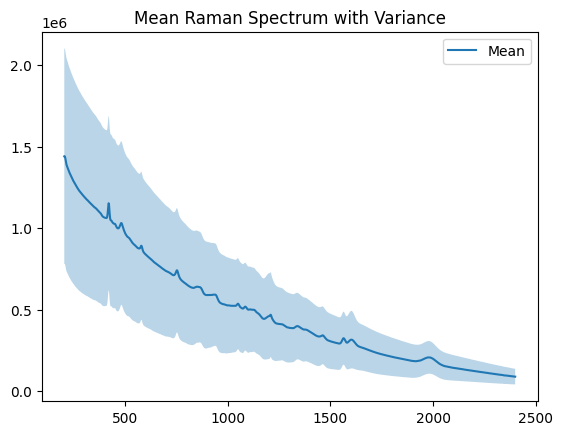

In [37]:
import numpy as np

mean_spectrum = df_clean[raman_cols].mean()
std_spectrum = df_clean[raman_cols].std()

plt.plot(range(203, 2401), mean_spectrum, label='Mean')
plt.fill_between(range(203, 2401),
                 mean_spectrum - std_spectrum,
                 mean_spectrum + std_spectrum,
                 alpha=0.3)

plt.title("Mean Raman Spectrum with Variance")
plt.legend()
plt.show()

#### Interpretation: 
- Raman signal is stronger at lower wavelengths
-  Higher wavelengths carry less information (low intensity + low variance)
-  Data is well-behaved and continuous

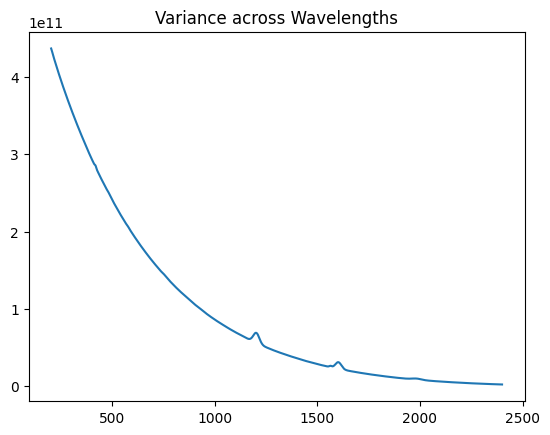

In [38]:
variance = df_clean[raman_cols].var()

plt.plot(range(203, 2401), variance)
plt.title("Variance across Wavelengths")
plt.show()

#### Interpretation:

- Lower wavelengths = most informative region
- High wavelengths = low signal → mostly noise/redundant
- Bumps = important chemical peaks

In [39]:
zero_rows = (df[raman_cols].sum(axis=1) == 0)

print("Rows with all zero Raman:", zero_rows.sum())

Rows with all zero Raman: 1000


In [40]:
df_clean.shape

(113935, 2232)

In [41]:
non_zero_mask = (df_clean[raman_cols].sum(axis=1) != 0)

df_clean = df_clean[non_zero_mask].copy()

print(df_clean.shape)

(112935, 2232)


### Performing PCA
As our dataset is high dimensional and have features correlated to each other 

In [42]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import numpy as np

In [43]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean[raman_cols])

In [44]:
pca_temp = PCA()
pca_temp.fit(X_scaled)

explained_variance = pca_temp.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

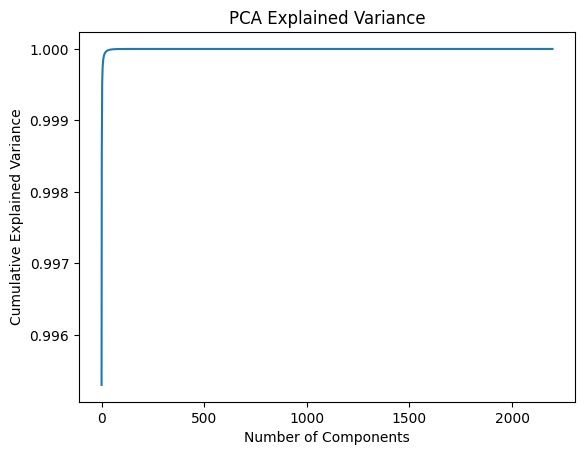

In [45]:
import matplotlib.pyplot as plt

plt.plot(cumulative_variance)
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.show()

#### What the above PCA Plot Shows

- The cumulative explained variance rises sharply to approximately **99.9% within the first few components**  
- Beyond this point, the curve becomes nearly flat  

**Interpretation:**  
Very few principal components are sufficient to capture almost all the variability in the Raman data.

---

#### Summary 

The Raman dataset exhibits a high degree of redundancy:

- Although there are approximately **2200 wavelength features**, the effective dimensionality is much lower  
- The data can be represented using roughly **5–10 principal components**  
- This indicates **strong correlation across neighboring wavelengths**  

In [46]:
n_components = 10

pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_scaled)

In [47]:
pca_cols = [f"PC{i+1}" for i in range(n_components)]
df_pca = pd.DataFrame(X_pca, columns=pca_cols, index=df_clean.index)

In [48]:
# Drop Raman columns
df_non_raman = df_clean.drop(columns=raman_cols)

# Combine
df_clean = pd.concat([df_non_raman, df_pca], axis=1)

In [49]:
print(df_clean.shape)
df_clean.head()

(112935, 44)


,time,Aeration rate(Fg:L/h),Agitator RPM(RPM:RPM),Sugar feed rate(Fs:L/h),Acid flow rate(Fa:L/h),Base flow rate(Fb:L/h),Heating/cooling water flow rate(Fc:L/h),Heating water flow rate(Fh:L/h),Water for injection/dilution(Fw:L/h),Air head pressure(pressure:bar),...,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
10,2.2,30,100,8,0.0,6.7741,1.6380,0.0001,0,0.6,...,-71.713411,-1.831894,-2.330973,-0.120925,0.240649,0.732816,-0.139471,-0.235823,0.051141,0.288255
11,2.4,30,100,8,0.0,18.1260,3.2411,0.0001,0,0.6,...,-63.620576,0.987983,1.586930,-0.368620,0.036662,0.124137,-0.279862,-0.761722,-0.077344,-0.052273
12,2.6,30,100,8,0.0,28.0370,5.2094,0.0001,0,0.6,...,-69.258223,0.057325,0.668527,1.084313,0.149251,-0.217047,0.333785,0.372894,-0.180378,0.226926
13,2.8,30,100,8,0.0,31.9080,7.4531,0.0001,0,0.6,...,-67.729673,0.622596,1.623030,0.794379,-0.097777,0.118070,0.400820,-0.019921,0.497082,-0.044086
14,3.0,30,100,8,0.0,28.3970,9.8571,0.0001,0,0.6,...,-70.559468,-0.091256,0.325649,-0.100176,-0.402052,0.325226,0.681061,0.062252,0.024109,0.193325


In [50]:
loadings = pca.components_

In [51]:
# sum of absolute loadings across PCs
importance = np.sum(np.abs(loadings[:10]), axis=0)

importance_series = pd.Series(importance, index=raman_cols)

top_wavelengths = importance_series.sort_values(ascending=False).head(10)

print(top_wavelengths)

2351    0.309755
2350    0.309741
2352    0.309587
2349    0.309563
2353    0.309251
2348    0.309224
2354    0.308747
2347    0.308730
2355    0.308070
2346    0.308069
dtype: float64


In [52]:
import joblib

joblib.dump(scaler, "scaler.pkl")

# scaler = joblib.load("scaler.pkl")

['scaler.pkl']

## C) Input features

### i) Analyzing

#### a) Substrate concentration(S:g/L)
Acc. to Dataset it is a not measurable in offline conditions and hence simulated so it is not act as feature

In [53]:
sensor_features = [
    'Aeration rate(Fg:L/h)',
    'Agitator RPM(RPM:RPM)',
    'Sugar feed rate(Fs:L/h)',
    'Acid flow rate(Fa:L/h)',
    'Base flow rate(Fb:L/h)',
    'Heating/cooling water flow rate(Fc:L/h)',
    'Heating water flow rate(Fh:L/h)',
    'Water for injection/dilution(Fw:L/h)',
    'Air head pressure(pressure:bar)',
    'Dumped broth flow(Fremoved:L/h)'
]
print(len(sensor_features))

10


In [54]:
online_features = [
    'Dissolved oxygen concentration(DO2:mg/L)',
    'Vessel Volume(V:L)',
    'Vessel Weight(Wt:Kg)',
    'pH(pH:pH)',
    'Temperature(T:K)',
    'Generated heat(Q:kJ)',
    'carbon dioxide percent in off-gas(CO2outgas:%)',
    'PAA flow(Fpaa:PAA flow (L/h))',
    'Oxygen in percent in off-gas(O2:O2  (%))',
    'Oxygen Uptake Rate(OUR:(g min^{-1}))',
    'Carbon evolution rate(CER:g/h)',
    'Oil flow(Foil:L/hr)',
    'Ammonia shots(NH3_shots:kgs)'
]
print(len(online_features))

13


In [55]:
input_features = sensor_features+online_features

#### b) checking for missing values

In [56]:
missing_df = pd.DataFrame({
    'null_count': df_clean[input_features].isnull().sum(),
    'null_percent': (df_clean[input_features].isnull().sum() / len(df_clean)) * 100
}).sort_values(by='null_percent', ascending=False)

print("\nMissing Value Summary:")
print(missing_df)


Missing Value Summary:
                                                null_count  null_percent
Aeration rate(Fg:L/h)                                    0           0.0
Agitator RPM(RPM:RPM)                                    0           0.0
Sugar feed rate(Fs:L/h)                                  0           0.0
Acid flow rate(Fa:L/h)                                   0           0.0
Base flow rate(Fb:L/h)                                   0           0.0
Heating/cooling water flow rate(Fc:L/h)                  0           0.0
Heating water flow rate(Fh:L/h)                          0           0.0
Water for injection/dilution(Fw:L/h)                     0           0.0
Air head pressure(pressure:bar)                          0           0.0
Dumped broth flow(Fremoved:L/h)                          0           0.0
Dissolved oxygen concentration(DO2:mg/L)                 0           0.0
Vessel Volume(V:L)                                       0           0.0
Vessel Weight(Wt:Kg)       

#### c) Distribution Plots

In [57]:
import matplotlib.pyplot as plt

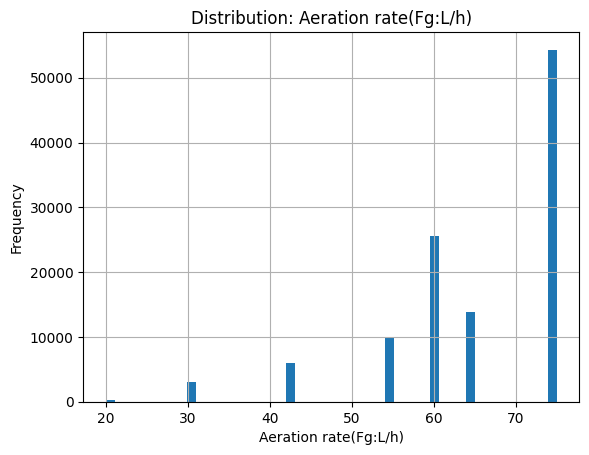

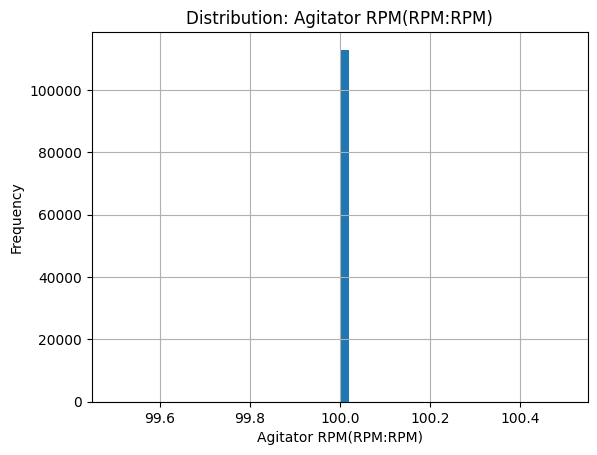

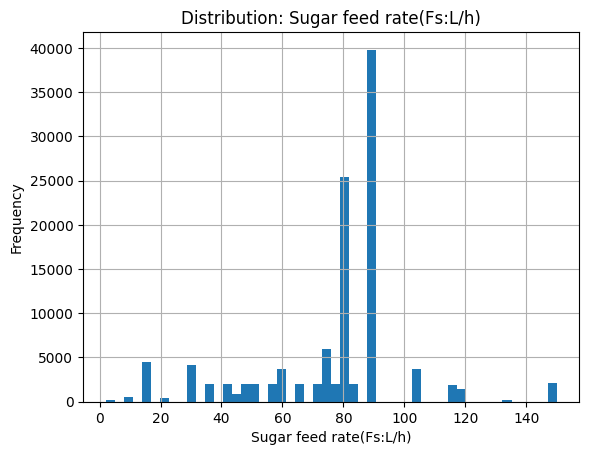

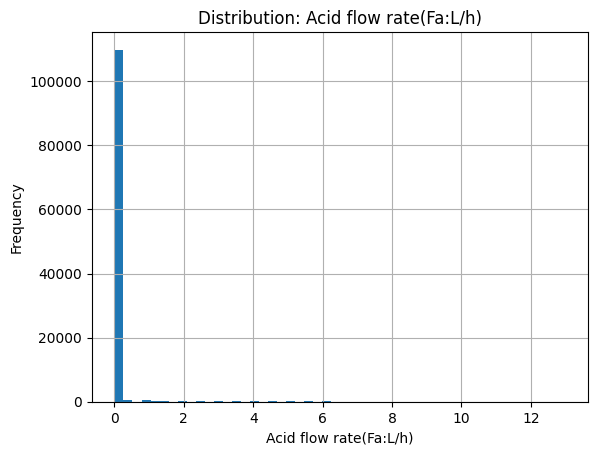

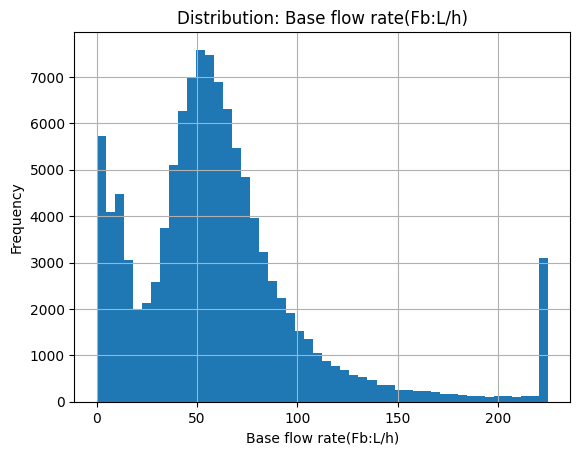

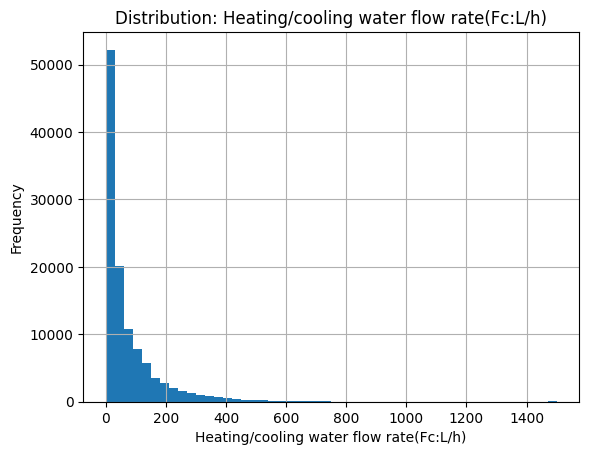

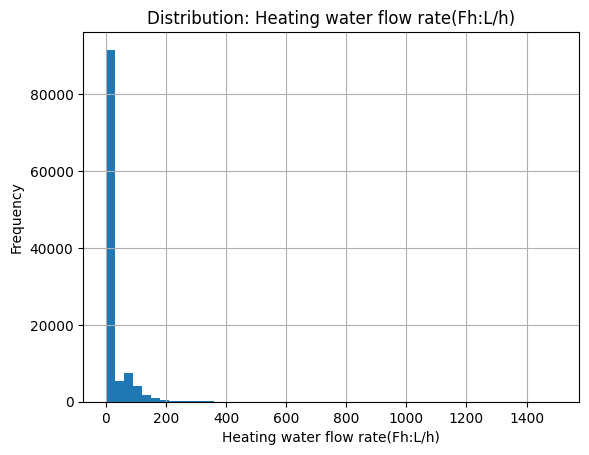

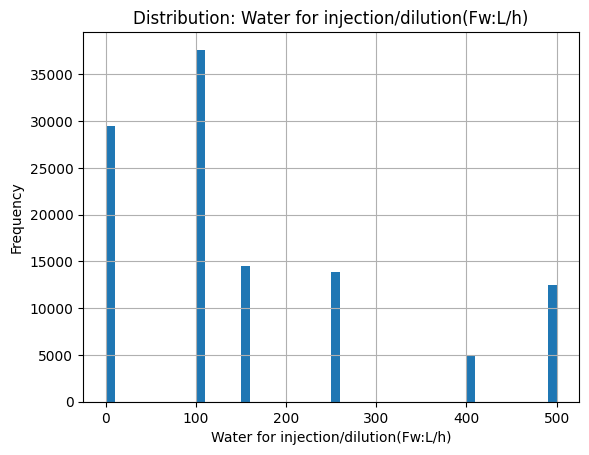

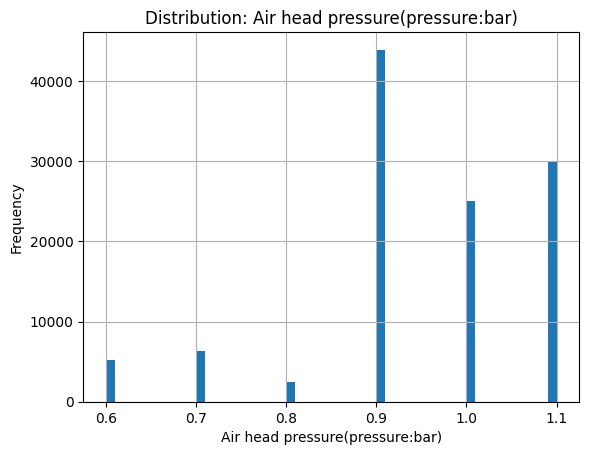

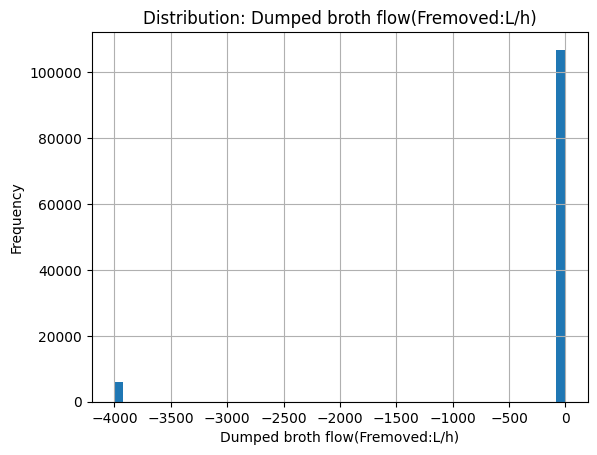

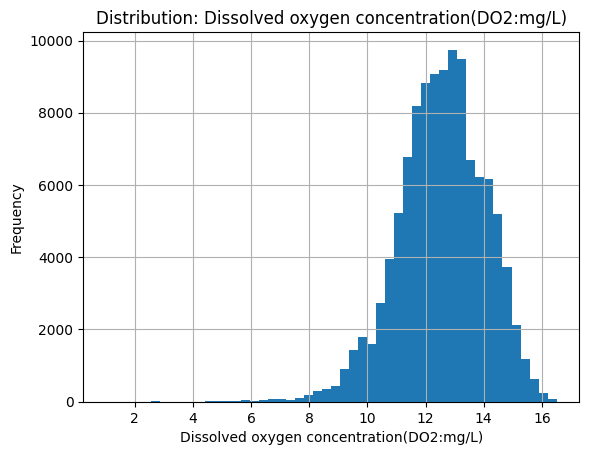

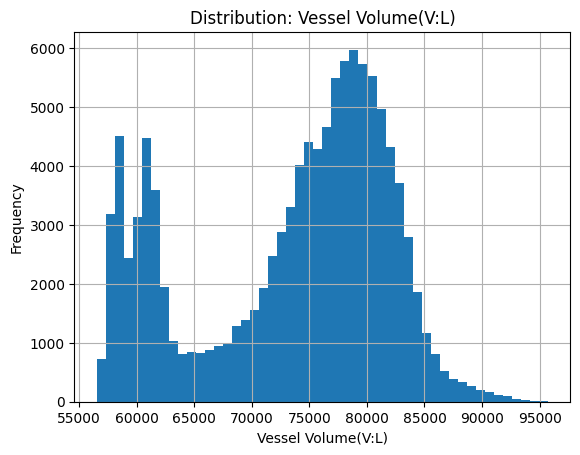

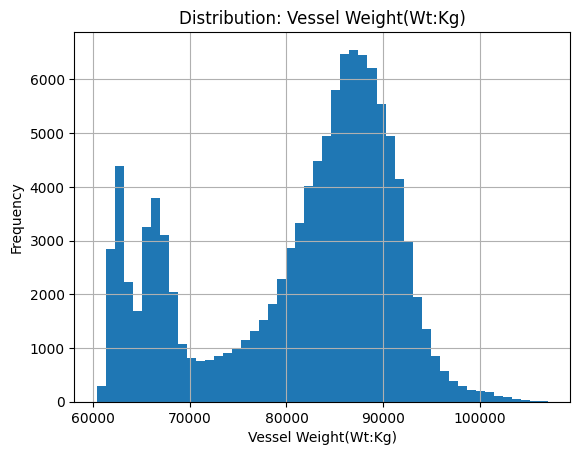

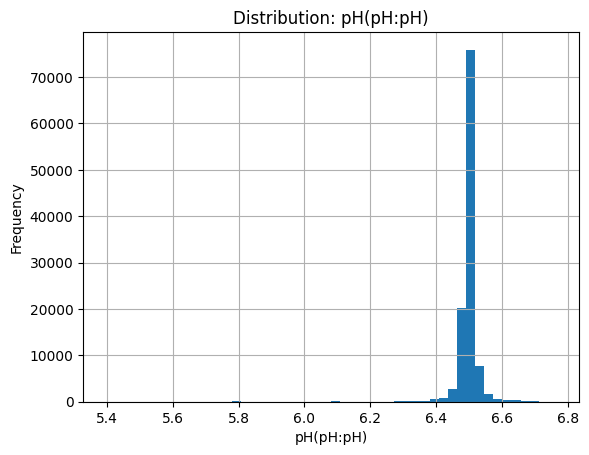

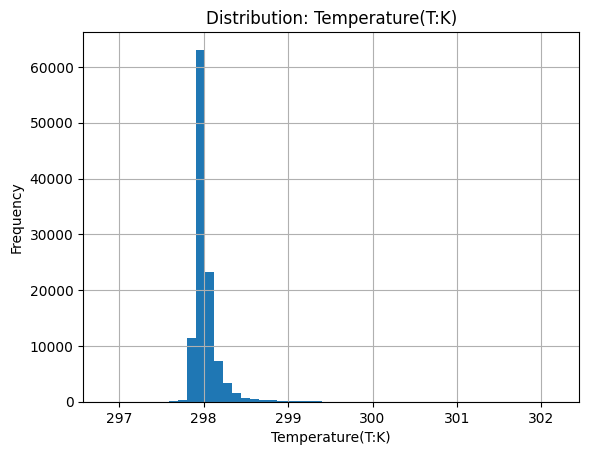

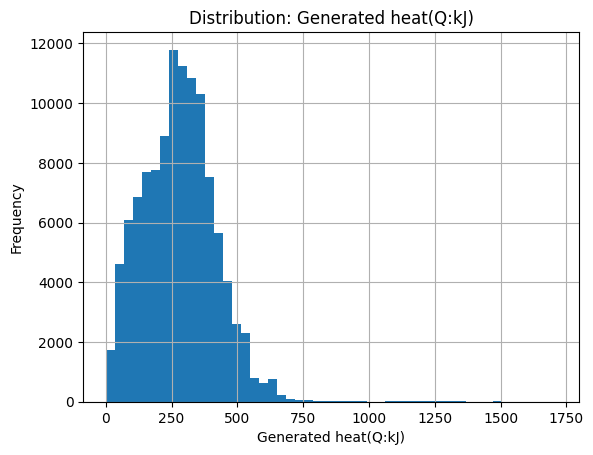

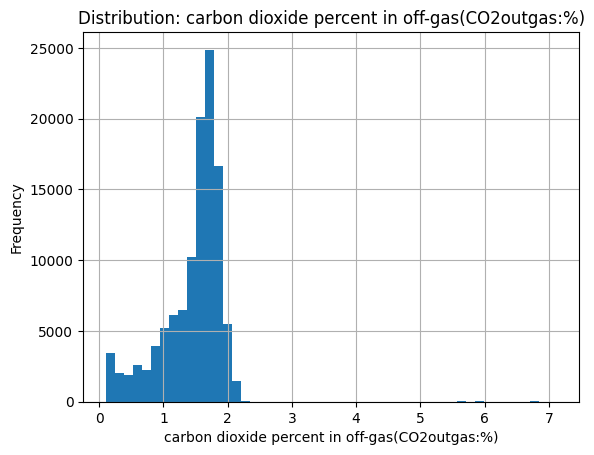

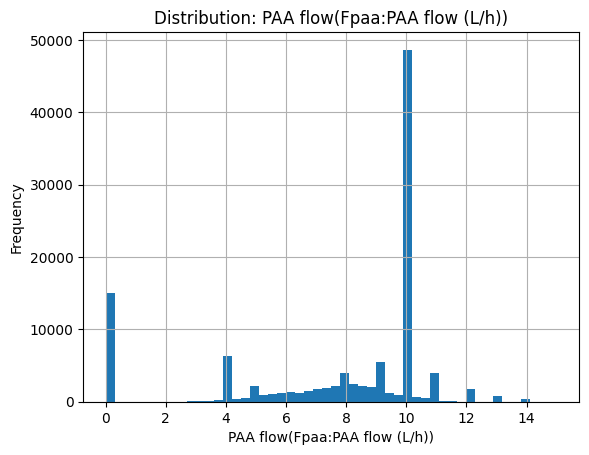

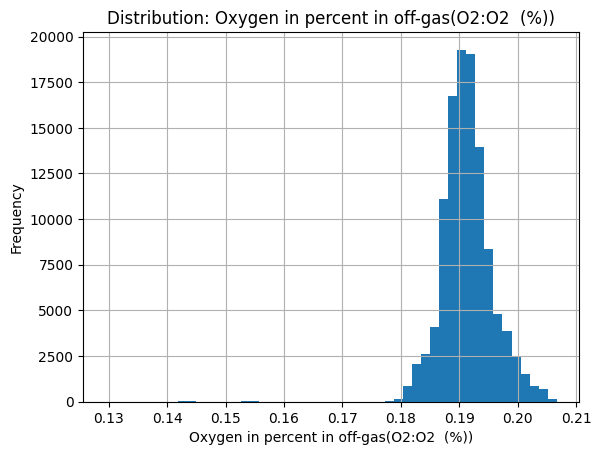

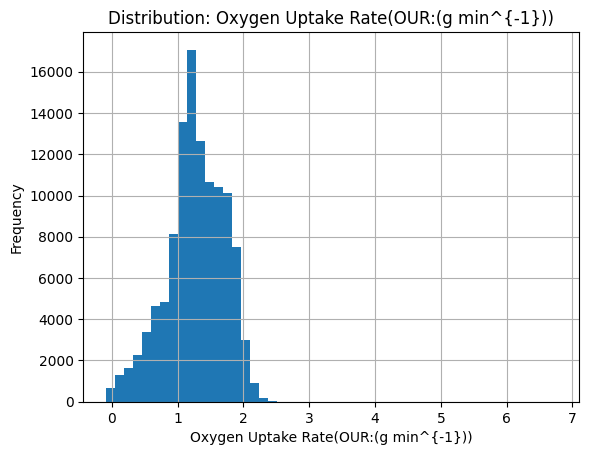

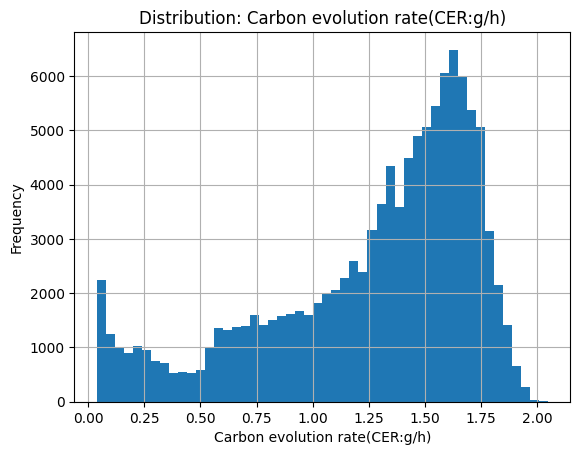

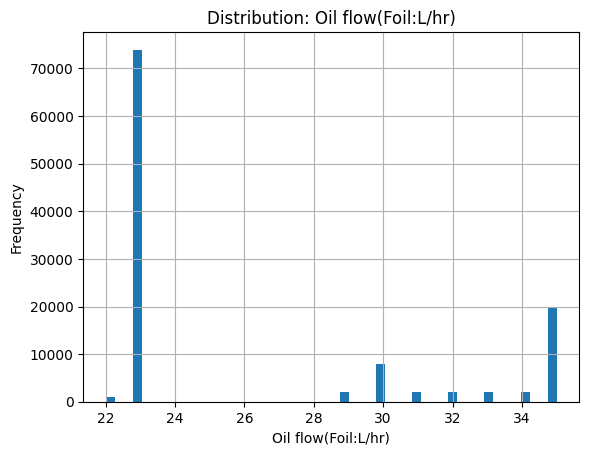

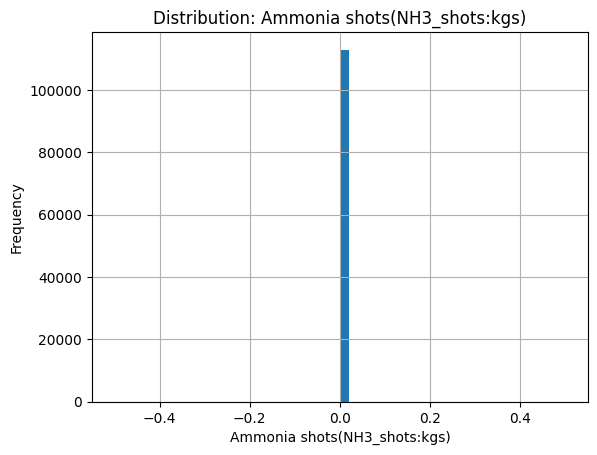

In [58]:
for col in input_features:
    plt.figure()
    df_clean[col].hist(bins=50)
    plt.title(f"Distribution: {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

From first plot we can see aertation rate is a controlled variable

In [59]:
if df_clean['Agitator RPM(RPM:RPM)'].nunique() <= 2:
    df_clean.drop(columns=['Agitator RPM(RPM:RPM)'], inplace=True)
    print('Agitator RPM(RPM:RPM) : dropped')

Agitator RPM(RPM:RPM) : dropped


In [60]:
df_clean['Acid flow rate(Fa:L/h)'].describe()

count    112935.000000
mean          0.071373
std           0.551329
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          12.996000
Name: Acid flow rate(Fa:L/h), dtype: float64

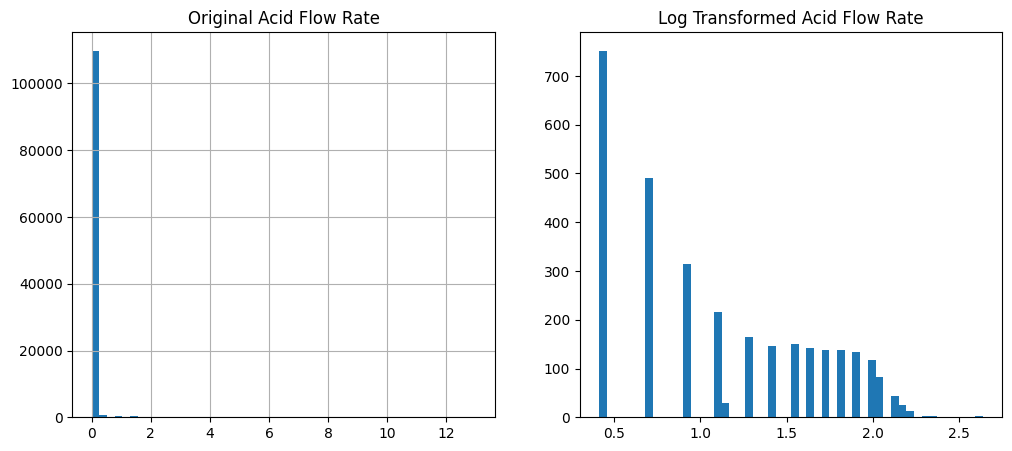

In [61]:
acid = df_clean['Acid flow rate(Fa:L/h)']
acid_log = np.log1p(acid[acid > 0])
plt.figure(figsize=(12, 5))

# Original
plt.subplot(1, 2, 1)
acid.hist(bins=50)
plt.title("Original Acid Flow Rate")

# Log-transformed
plt.subplot(1, 2, 2)
plt.hist(acid_log, bins=50)
plt.title("Log Transformed Acid Flow Rate")

plt.show()

In [62]:
print(df_clean.shape)
df_clean['acid_flow_rate_log'] = acid_log
df_clean = df_clean.drop(columns=['Acid flow rate(Fa:L/h)'])
print(df_clean.shape)

(112935, 43)
(112935, 43)


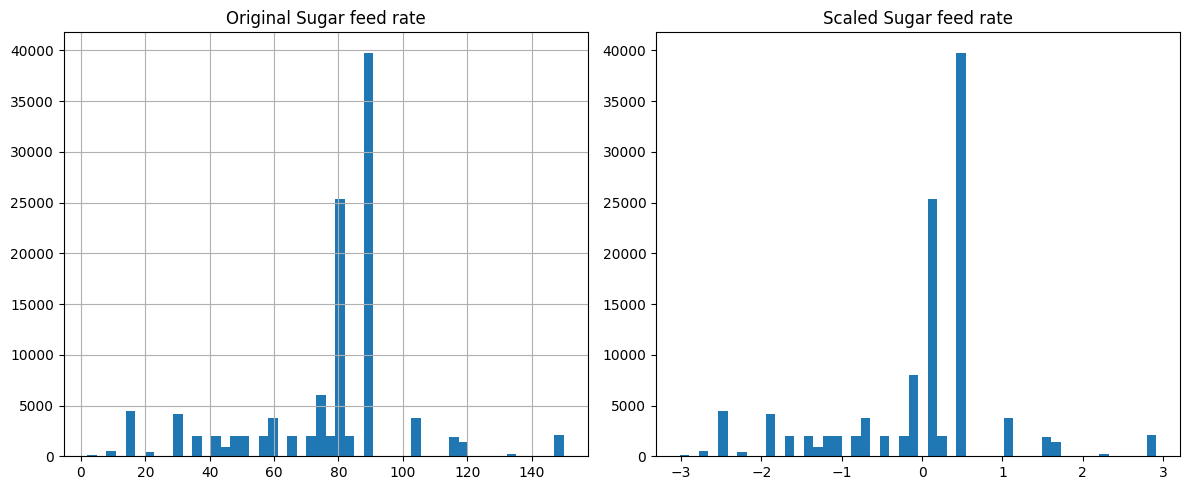

In [63]:
scaler_Fs = StandardScaler()

Fs_scaled = scaler_Fs.fit_transform(df_clean[['Sugar feed rate(Fs:L/h)']])

plt.figure(figsize=(12, 5))

# Original
plt.subplot(1, 2, 1)
df_clean['Sugar feed rate(Fs:L/h)'].hist(bins=50)
plt.title("Original Sugar feed rate")

# Scaled
plt.subplot(1, 2, 2)
plt.hist(Fs_scaled, bins=50)
plt.title("Scaled Sugar feed rate")

plt.tight_layout()
plt.show()

In [64]:
print(df_clean.shape)
df_clean['sugar_feed_rate_scaled'] = Fs_scaled
df_clean = df_clean.drop(columns=['Sugar feed rate(Fs:L/h)'])
print(df_clean.shape)

(112935, 43)
(112935, 43)


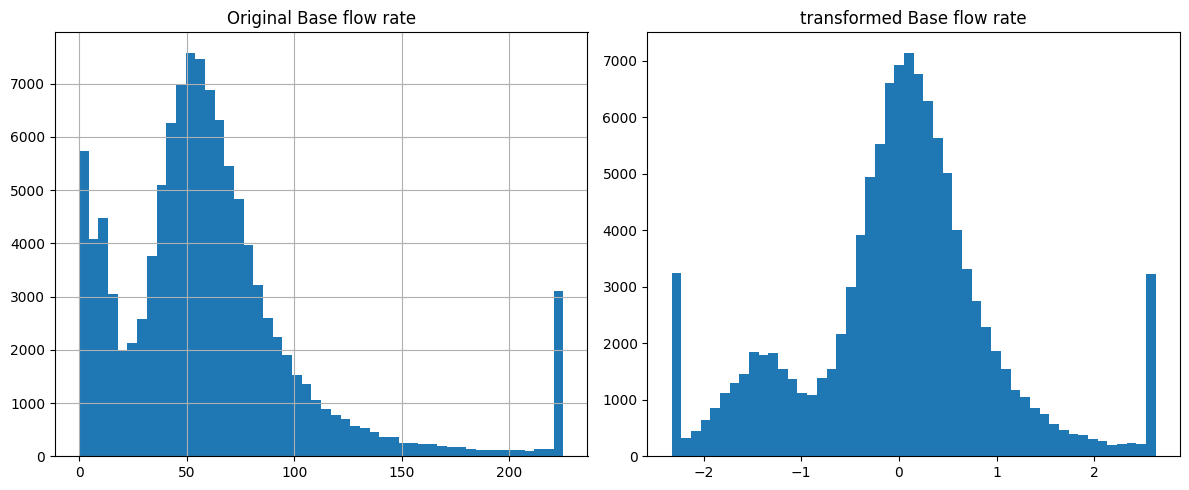

In [65]:
# data in this col is right skewed hitting 220 repetedly
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method='yeo-johnson')
Fb_transformed = pt.fit_transform(df_clean[['Base flow rate(Fb:L/h)']])

plt.figure(figsize=(12, 5))

# Original
plt.subplot(1, 2, 1)
df_clean['Base flow rate(Fb:L/h)'].hist(bins=50)
plt.title("Original Base flow rate")

# Transformed
plt.subplot(1, 2, 2)
plt.hist(Fb_transformed, bins=50)
plt.title("transformed Base flow rate")

plt.tight_layout()
plt.show()

In [66]:
print(df_clean.shape)
df_clean['Fb_transformedBase flow rate(Fb:L/h)'] = Fb_transformed
df_clean = df_clean.drop(columns=['Base flow rate(Fb:L/h)'])
print(df_clean.shape)

(112935, 43)
(112935, 43)


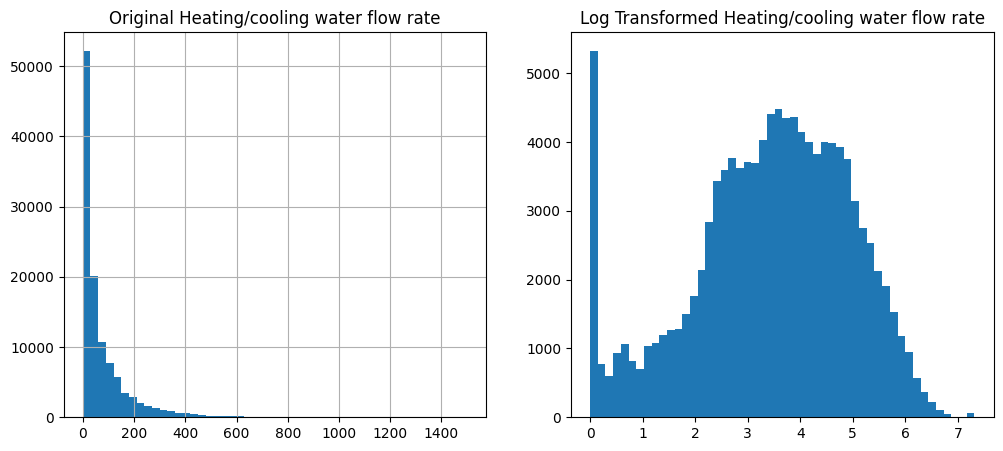

In [67]:
# log1p handles zeros + extreme right skew
Fc_log = np.log1p(df_clean['Heating/cooling water flow rate(Fc:L/h)'])
plt.figure(figsize=(12, 5))

# Original
plt.subplot(1, 2, 1)
df_clean['Heating/cooling water flow rate(Fc:L/h)'].hist(bins=50)
plt.title("Original Heating/cooling water flow rate")

# Log-transformed
plt.subplot(1, 2, 2)
plt.hist(Fc_log, bins=50)
plt.title("Log Transformed Heating/cooling water flow rate")

plt.show()

In [68]:
print(df_clean.shape)
df_clean['Log Heating/cooling water flow rate(log Fc)'] = Fc_log
df_clean = df_clean.drop(columns=['Heating/cooling water flow rate(Fc:L/h)'])
print(df_clean.shape)

(112935, 43)
(112935, 43)


In [69]:
print(df_clean.shape)
df_clean['Log Heating water flow rate(log Fh)'] = np.log1p(df_clean['Heating water flow rate(Fh:L/h)'])
df_clean = df_clean.drop(columns=['Heating water flow rate(Fh:L/h)'])
print(df_clean.shape)

(112935, 43)
(112935, 43)


In [70]:
std_cols = [
    'Water for injection/dilution(Fw:L/h)',
    'Air head pressure(pressure:bar)',
    'Aeration rate(Fg:L/h)'
]

scaler = StandardScaler()
df_clean[std_cols] = scaler.fit_transform(df_clean[std_cols])

In [71]:
df_clean.columns

Index(['time', 'Aeration rate(Fg:L/h)', 'Water for injection/dilution(Fw:L/h)',
       'Air head pressure(pressure:bar)', 'Dumped broth flow(Fremoved:L/h)',
       'Substrate concentration(S:g/L)',
       'Dissolved oxygen concentration(DO2:mg/L)',
       'Penicillin concentration(P:g/L)', 'Vessel Volume(V:L)',
       'Vessel Weight(Wt:Kg)', 'pH(pH:pH)', 'Temperature(T:K)',
       'Generated heat(Q:kJ)',
       'carbon dioxide percent in off-gas(CO2outgas:%)',
       'PAA flow(Fpaa:PAA flow (L/h))',
       'PAA concentration offline(PAA_offline:PAA (g L^{-1}))',
       'Oil flow(Foil:L/hr)',
       'NH_3 concentration off-line(NH3_offline:NH3 (g L^{-1}))',
       'Oxygen Uptake Rate(OUR:(g min^{-1}))',
       'Oxygen in percent in off-gas(O2:O2  (%))',
       'Offline Penicillin concentration(P_offline:P(g L^{-1}))',
       'Offline Biomass concentratio(X_offline:X(g L^{-1}))',
       'Carbon evolution rate(CER:g/h)', 'Ammonia shots(NH3_shots:kgs)',
       'Viscosity(Viscosity_offline:

In [72]:
df_clean['Dumped broth flow(Fremoved:L/h)'].nunique()

2

In [73]:
# Convert to binary flag — 1 means dumping is active
df_clean['Fremoved_flag'] = (df_clean['Dumped broth flow(Fremoved:L/h)'] < 0).astype(int)

# Drop original
df_clean.drop(columns=['Dumped broth flow(Fremoved:L/h)'], inplace=True)

# Verify
print(df_clean['Fremoved_flag'].value_counts())

Fremoved_flag
0    106825
1      6110
Name: count, dtype: int64


In [74]:
# slightly left skewed but a good bell shaped so only scaling is done
df_clean['DO2_scaled'] = StandardScaler().fit_transform(
    df_clean[['Dissolved oxygen concentration(DO2:mg/L)']]
)
df_clean.drop(columns=['Dissolved oxygen concentration(DO2:mg/L)'], inplace=True)

In [75]:
df_clean['V_scaled'] = StandardScaler().fit_transform(
    df_clean[['Vessel Volume(V:L)']]
)
df_clean.drop(columns=['Vessel Volume(V:L)'], inplace=True)

In [76]:
df_clean['Wt_scaled'] = StandardScaler().fit_transform(
    df_clean[['Vessel Weight(Wt:Kg)']]
)
df_clean.drop(columns=['Vessel Weight(Wt:Kg)'], inplace=True)

This is the most tightly controlled variable in the entire dataset — PID controller keeps it almost perfectly at setpoint. Nearly 75,000+ rows sit at exactly pH 6.5 with very tiny deviations. So dropping it makes sense

In [77]:
print(df_clean['pH(pH:pH)'].std())   # near 0
print(df_clean['pH(pH:pH)'].nunique())  # very few unique values

0.06573568931493137
3954


In [78]:
df_clean.drop(columns=['pH(pH:pH)'], inplace=True)

Applying same reasoning as of pH to Temperature it can also be dropped

In [79]:
print(df_clean['Temperature(T:K)'].std())   # expect near 0
print(df_clean['Temperature(T:K)'].nunique())  # expect very few unique values

0.19786949390810898
390


In [80]:
df_clean.drop(columns=['Temperature(T:K)'], inplace=True)

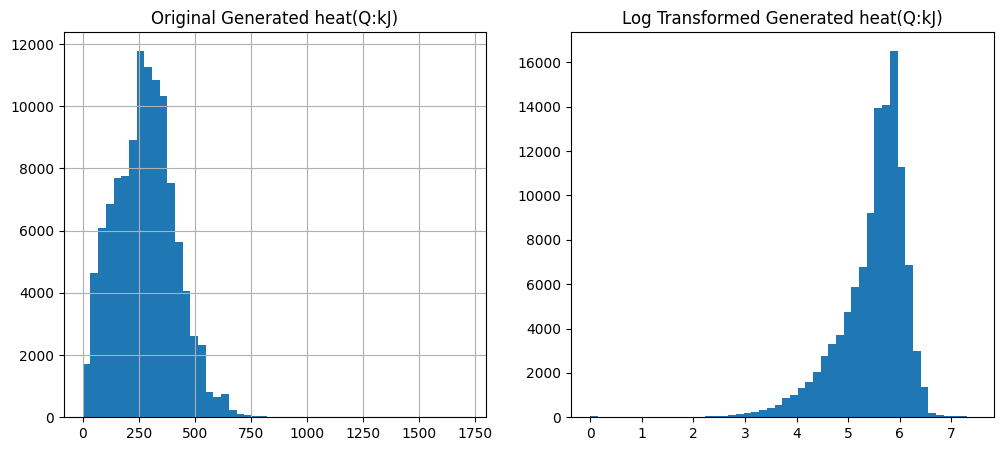

In [81]:
# log1p handles zeros + extreme right skew
Q_log = np.log1p(df_clean['Generated heat(Q:kJ)'])
plt.figure(figsize=(12, 5))

# Original
plt.subplot(1, 2, 1)
df_clean['Generated heat(Q:kJ)'].hist(bins=50)
plt.title("Original Generated heat(Q:kJ)")

# Log-transformed
plt.subplot(1, 2, 2)
plt.hist(Q_log, bins=50)
plt.title("Log Transformed Generated heat(Q:kJ)")

plt.show()

In [82]:
df_clean['Q_log'] = Q_log
df_clean.drop(columns=['Generated heat(Q:kJ)'], inplace=True)

In [83]:
df_clean['CO2outgas_log'] = np.log1p(df_clean['carbon dioxide percent in off-gas(CO2outgas:%)'])
df_clean.drop(columns=['carbon dioxide percent in off-gas(CO2outgas:%)'], inplace=True)

In [84]:
df_clean['Fpaa_scaled'] = StandardScaler().fit_transform(
    df_clean[['PAA flow(Fpaa:PAA flow (L/h))']]
)
df_clean.drop(columns=['PAA flow(Fpaa:PAA flow (L/h))'], inplace=True)

In [85]:
#nearly bell shaped so scaling would work
df_clean['O2_scaled'] = StandardScaler().fit_transform(
    df_clean[['Oxygen in percent in off-gas(O2:O2  (%))']]
)
df_clean.drop(columns=['Oxygen in percent in off-gas(O2:O2  (%))'], inplace=True)

In [86]:
# Check how many negative values exist
print(df_clean['Oxygen Uptake Rate(OUR:(g min^{-1}))'].lt(0).sum())

# Clip negatives to 0 (physically impossible values)
df_clean['Oxygen Uptake Rate(OUR:(g min^{-1}))'] = df_clean['Oxygen Uptake Rate(OUR:(g min^{-1}))'].clip(lower=0)

# Then apply log1p
df_clean['OUR_log'] = np.log1p(df_clean['Oxygen Uptake Rate(OUR:(g min^{-1}))'])
df_clean.drop(columns=['Oxygen Uptake Rate(OUR:(g min^{-1}))'], inplace=True)

218


In [87]:
# near-zero cluster = early batch phase when fungus is just starting to grow. The main peak = active fermentation. This is a meaningful bimodal pattern
df_clean['CER_scaled'] = StandardScaler().fit_transform(
    df_clean[['Carbon evolution rate(CER:g/h)']]
)
df_clean.drop(columns=['Carbon evolution rate(CER:g/h)'], inplace=True)

In [88]:
# discrete multimodal
df_clean['Foil_scaled'] = StandardScaler().fit_transform(
    df_clean[['Oil flow(Foil:L/hr)']]
)
df_clean.drop(columns=['Oil flow(Foil:L/hr)'], inplace=True)

In [89]:
df_clean.shape

(112935, 41)

In [90]:
df_clean['Ammonia shots(NH3_shots:kgs)'].value_counts()

Ammonia shots(NH3_shots:kgs)
0    112935
Name: count, dtype: int64

In [91]:
df_clean.drop(columns=['Ammonia shots(NH3_shots:kgs)'], inplace=True)

In [92]:
input_features = [
 
        'Aeration rate(Fg:L/h)', 
        'Water for injection/dilution(Fw:L/h)',
        'Air head pressure(pressure:bar)', 
        'acid_flow_rate_log', 
        'sugar_feed_rate_scaled',
        'Fb_transformedBase flow rate(Fb:L/h)',
        'Log Heating/cooling water flow rate(log Fc)',
        'Log Heating water flow rate(log Fh)',
        'Fremoved_flag', 
        'DO2_scaled',
        'V_scaled', 
        'Wt_scaled',
        'Q_log', 
        'CO2outgas_log',
        'Fpaa_scaled',
        'O2_scaled', 
        'OUR_log', 
        'CER_scaled', 
        'Foil_scaled'
    ]

#### d) Analyzing correlation

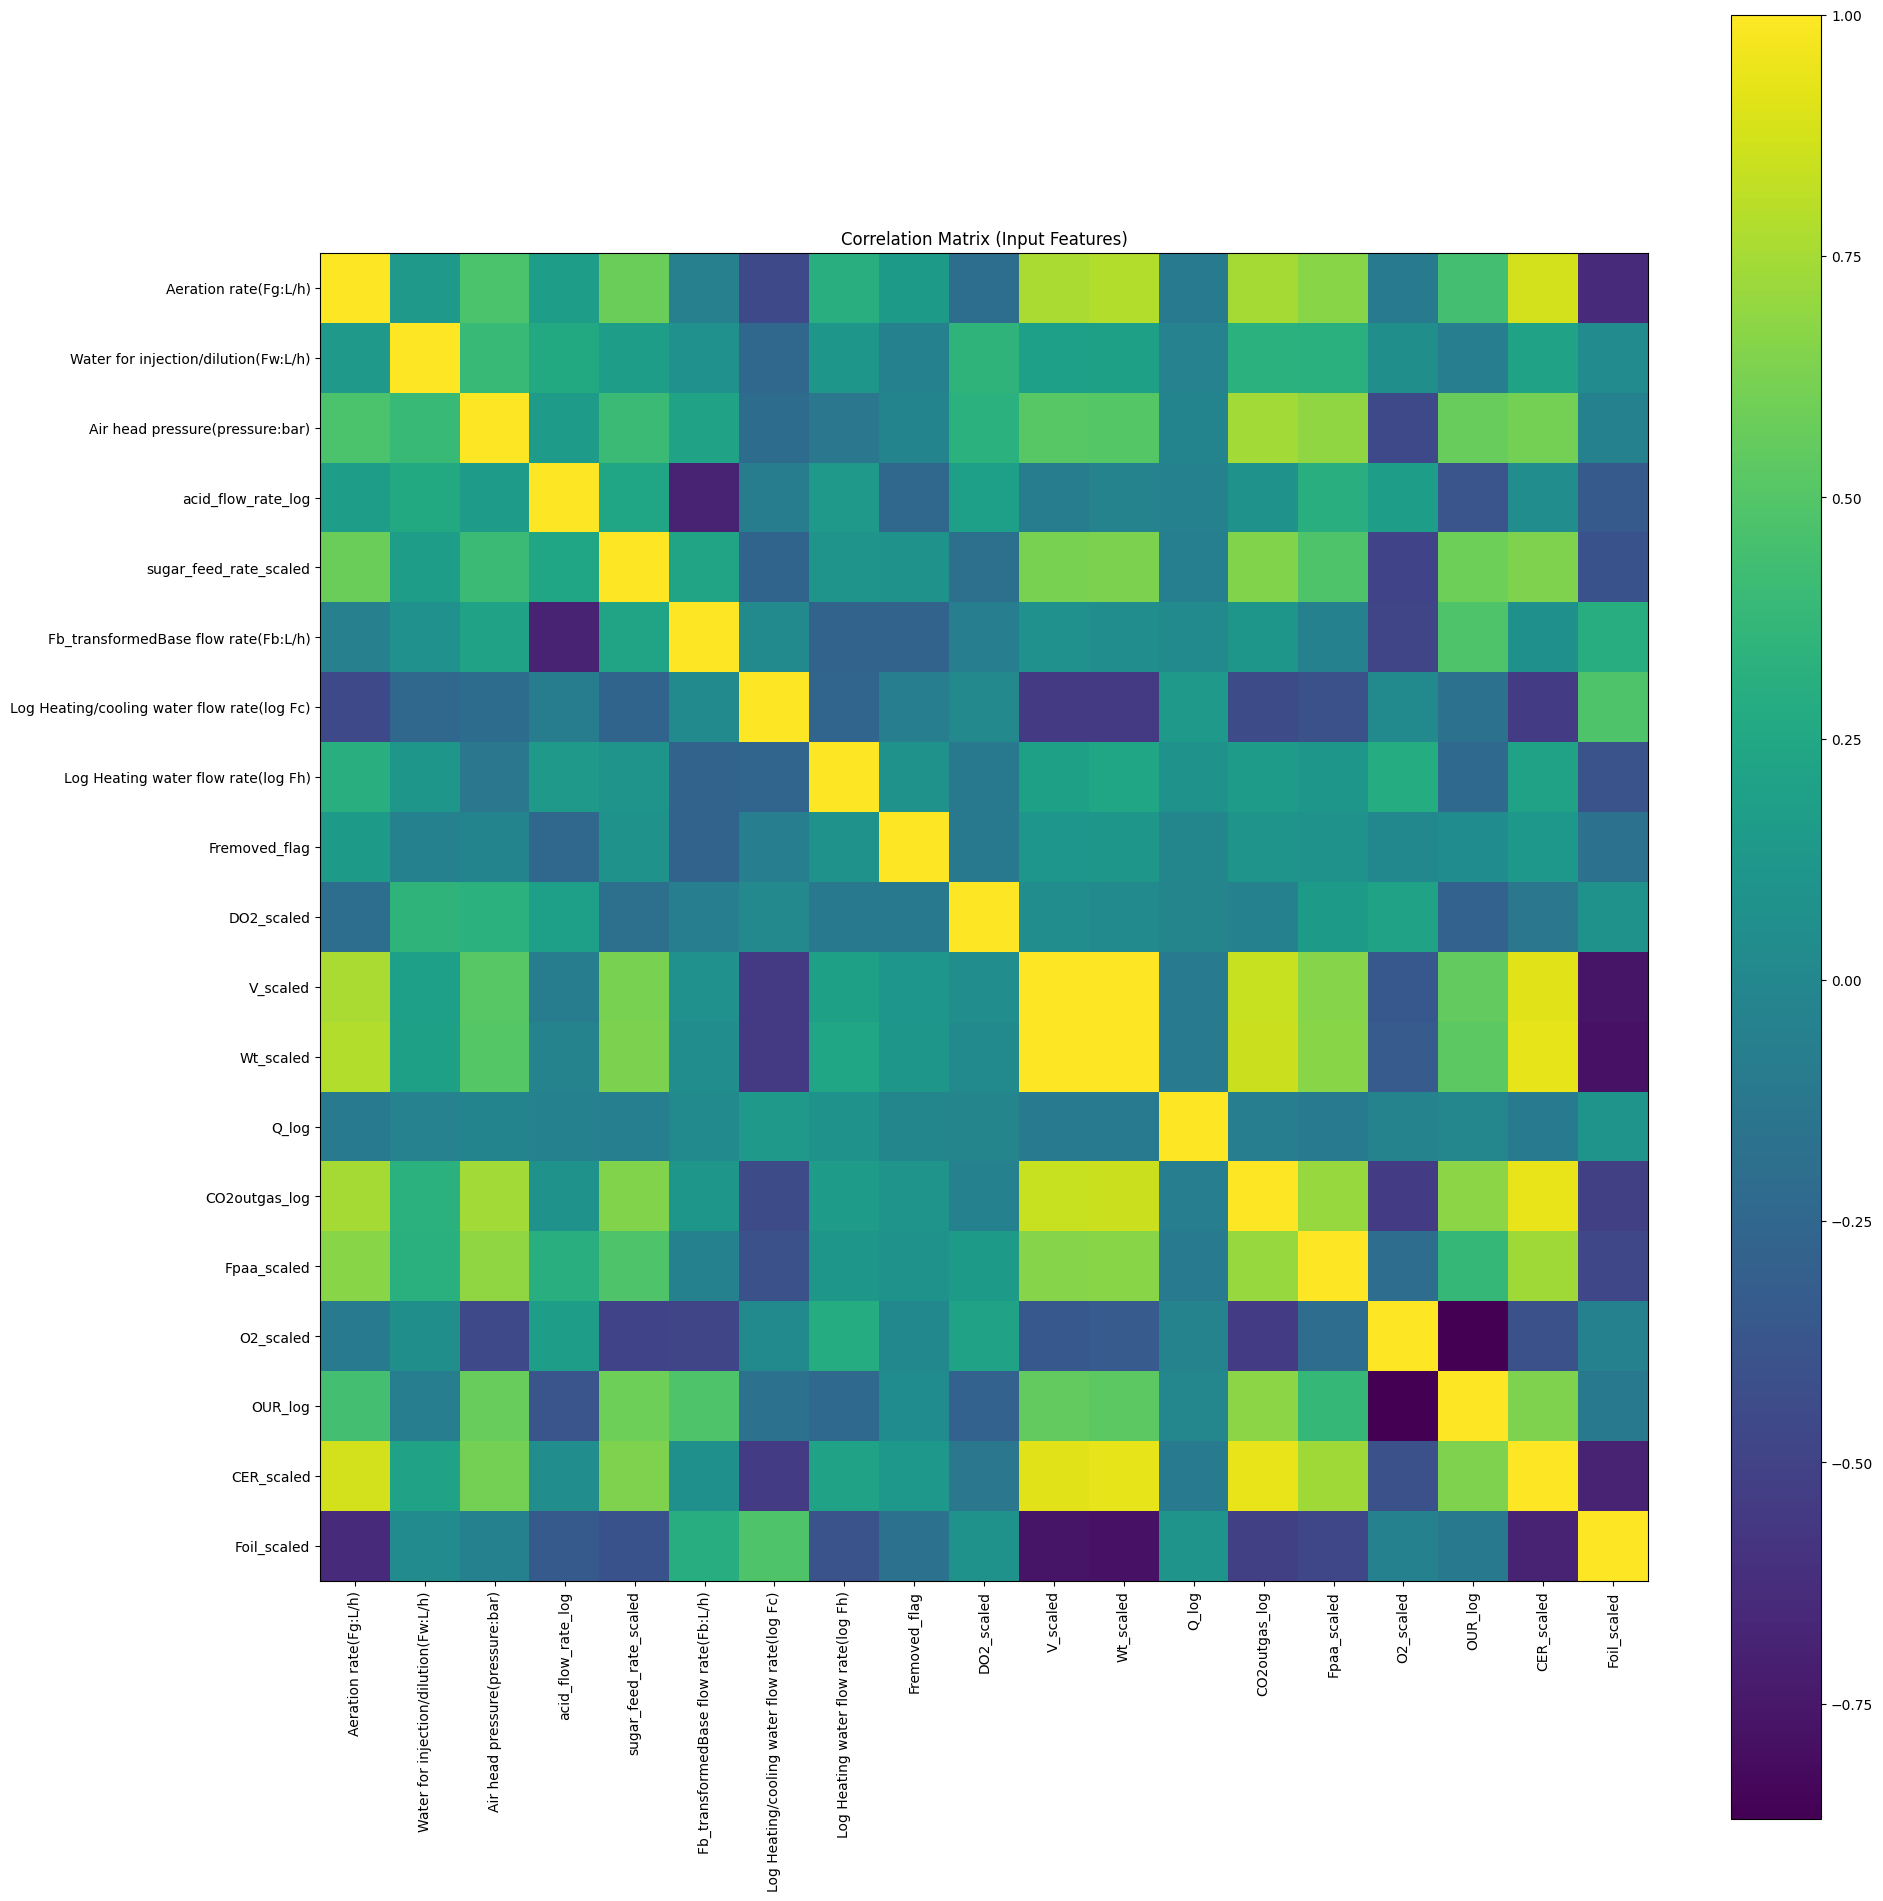

In [93]:
corr_matrix = df_clean[input_features].corr()

plt.figure(figsize=(20, 20))
plt.imshow(corr_matrix, cmap='viridis')
plt.colorbar()

plt.xticks(ticks=range(len(corr_matrix.columns)), 
           labels=corr_matrix.columns, 
           rotation=90,
           fontsize=10)

plt.yticks(ticks=range(len(corr_matrix.columns)), 
           labels=corr_matrix.columns,
           fontsize=10)

plt.title("Correlation Matrix (Input Features)")
plt.tight_layout()
plt.show()

In [94]:
import numpy as np

threshold = 0.9
upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Find pairs above threshold
high_corr_pairs = (
    upper_triangle.stack()
    .reset_index()
    .rename(columns={'level_0': 'Feature_1', 
                     'level_1': 'Feature_2', 
                     0: 'Correlation'})
    .query('abs(Correlation) >= @threshold')
    .sort_values('Correlation', ascending=False)
    .reset_index(drop=True)
)

print(f"Highly correlated pairs (|r| >= {threshold}):\n")
print(high_corr_pairs.to_string(index=False))

Highly correlated pairs (|r| >= 0.9):

    Feature_1  Feature_2  Correlation
     V_scaled  Wt_scaled     0.994682
CO2outgas_log CER_scaled     0.937924
    Wt_scaled CER_scaled     0.929556
     V_scaled CER_scaled     0.918870


In [95]:
# Drop the weaker/more redundant of each highly correlated pair
cols_to_drop = [
    'Wt_scaled',       # V_scaled carries same info
    'CO2outgas_log',   # CER_scaled is more informative
]

df_clean.drop(columns=cols_to_drop, inplace=True)

In [96]:
# Also remove from input_features list
input_features = [col for col in input_features if col not in cols_to_drop]
print("Remaining features:", len(input_features))
print("\nFinal feature list:")
for col in input_features:
    print(col)

Remaining features: 17

Final feature list:
Aeration rate(Fg:L/h)
Water for injection/dilution(Fw:L/h)
Air head pressure(pressure:bar)
acid_flow_rate_log
sugar_feed_rate_scaled
Fb_transformedBase flow rate(Fb:L/h)
Log Heating/cooling water flow rate(log Fc)
Log Heating water flow rate(log Fh)
Fremoved_flag
DO2_scaled
V_scaled
Q_log
Fpaa_scaled
O2_scaled
OUR_log
CER_scaled
Foil_scaled


In [97]:
# Fix acid_flow_rate_log — replace NaN with 0
# Zero means acid pump was off — a valid physical state
df_clean['acid_flow_rate_log'] = df_clean['acid_flow_rate_log'].fillna(0)

# Also fix any inf values
df_clean['acid_flow_rate_log'] = df_clean['acid_flow_rate_log'].replace(
    [np.inf, -np.inf], 0
)

In [98]:
# Verify
print(f"NaN remaining : {df_clean['acid_flow_rate_log'].isna().sum()}")
print(f"Inf remaining : {np.isinf(df_clean['acid_flow_rate_log']).sum()}")
print(f"Value range   : {df_clean['acid_flow_rate_log'].min():.4f} → {df_clean['acid_flow_rate_log'].max():.4f}")

NaN remaining : 0
Inf remaining : 0
Value range   : 0.0000 → 2.6388


#### e) Analyzing Outliers

In [99]:
outlier_summary = {}

for col in input_features:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    
    outliers = df_clean[(df_clean[col] < (Q1 - 1.5 * IQR)) | (df_clean[col] > (Q3 + 1.5 * IQR))]
    
    outlier_summary[col] = len(outliers)

outlier_df = pd.DataFrame.from_dict(outlier_summary, orient='index', columns=['outlier_count'])

print("\nOutlier Summary:")
print(outlier_df.sort_values(by='outlier_count', ascending=False))


Outlier Summary:
                                             outlier_count
sugar_feed_rate_scaled                               17479
Fpaa_scaled                                          14970
Fb_transformedBase flow rate(Fb:L/h)                 10121
Fremoved_flag                                         6110
Q_log                                                 5046
OUR_log                                               4868
O2_scaled                                             4118
Aeration rate(Fg:L/h)                                 3216
acid_flow_rate_log                                    3106
DO2_scaled                                            1301
CER_scaled                                            1237
Log Heating water flow rate(log Fh)                     73
Air head pressure(pressure:bar)                          0
Log Heating/cooling water flow rate(log Fc)              0
Water for injection/dilution(Fw:L/h)                     0
V_scaled                              

As we seen from distribution : sugar_feed_rate_scaled, Fpaa_scaled, Fremoved_flag, Aeration rate(Fg:L/h), Air head pressure are discrete mulimodal so these are false outliers

In [100]:
for col in ['Oxygen Uptake Rate(OUR:(g min^{-1}))', 'Generated heat(Q:kJ)', 'Oxygen in percent in off-gas(O2:O2  (%))', 'Dissolved oxygen concentration(DO2:mg/L)', 'Carbon evolution rate(CER:g/h)','Heating water flow rate(Fh:L/h)','Base flow rate(Fb:L/h)']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    mask = (df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)
    print(f"\n{col} outliers by Fault_ref:")
    print(df[mask]['Fault reference(Fault_ref:Fault ref)'].value_counts())


Oxygen Uptake Rate(OUR:(g min^{-1})) outliers by Fault_ref:
Fault reference(Fault_ref:Fault ref)
0    2443
1       1
Name: count, dtype: int64

Generated heat(Q:kJ) outliers by Fault_ref:
Fault reference(Fault_ref:Fault ref)
0    658
1    126
Name: count, dtype: int64

Oxygen in percent in off-gas(O2:O2  (%)) outliers by Fault_ref:
Fault reference(Fault_ref:Fault ref)
0    4573
1     324
Name: count, dtype: int64

Dissolved oxygen concentration(DO2:mg/L) outliers by Fault_ref:
Fault reference(Fault_ref:Fault ref)
0    1208
1      58
Name: count, dtype: int64

Carbon evolution rate(CER:g/h) outliers by Fault_ref:
Series([], Name: count, dtype: int64)

Heating water flow rate(Fh:L/h) outliers by Fault_ref:
Fault reference(Fault_ref:Fault ref)
0    21636
1      283
Name: count, dtype: int64

Base flow rate(Fb:L/h) outliers by Fault_ref:
Fault reference(Fault_ref:Fault ref)
0    6574
1      83
Name: count, dtype: int64


##### Cross-checking with Fault_ref reveals that 93–99% of flagged outliers in process variables originate from NORMAL operation batches (Fault_ref = 0), not fault batches. This confirms they represent genuine biological variability in fermentation, not measurement errors or noise. Removing them would delete legitimate training signal.

In [101]:
# Clip physically impossible negative OUR values
df_clean['OUR_log'] = df_clean['OUR_log'].clip(lower=0)

In [102]:
# Rename scaled columns to cleaner names
df_clean.rename(columns={
    'Aeration rate(Fg:L/h)': 'Fg_scaled',
    'Water for injection/dilution(Fw:L/h)': 'Fw_scaled',
    'Air head pressure(pressure:bar)': 'pressure_scaled'
}, inplace=True)

rename_map = {
    'Aeration rate(Fg:L/h)': 'Fg_scaled',
    'Water for injection/dilution(Fw:L/h)': 'Fw_scaled',
    'Air head pressure(pressure:bar)': 'pressure_scaled'
}

input_features = [rename_map.get(col, col) for col in input_features]

## D) Offline/Target variables

In [103]:
output_features = [
        'Substrate concentration(S:g/L)', 
        'Penicillin concentration(P:g/L)',
        'PAA concentration offline(PAA_offline:PAA (g L^{-1}))',
        'NH_3 concentration off-line(NH3_offline:NH3 (g L^{-1}))',
        'Offline Penicillin concentration(P_offline:P(g L^{-1}))',
        'Offline Biomass concentratio(X_offline:X(g L^{-1}))',
        'Viscosity(Viscosity_offline:centPoise)'
]

Correlation between P and P_offline: 1.0000


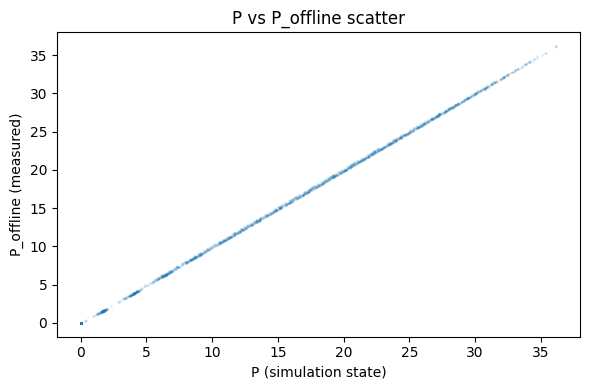

In [104]:
# Check correlation between online and offline penicillin
corr = df_clean['Penicillin concentration(P:g/L)'].corr(
    df_clean['Offline Penicillin concentration(P_offline:P(g L^{-1}))']
)
print(f"Correlation between P and P_offline: {corr:.4f}")

plt.figure(figsize=(6, 4))
plt.scatter(df_clean['Penicillin concentration(P:g/L)'], 
            df_clean['Offline Penicillin concentration(P_offline:P(g L^{-1}))'],
            alpha=0.1, s=1)
plt.xlabel('P (simulation state)')
plt.ylabel('P_offline (measured)')
plt.title('P vs P_offline scatter')
plt.tight_layout()
plt.show()

**Penicilin and Substrate conc. are simulated not derived or measured offline so we can drop these cols.**

In [105]:
out_cols_to_drop = [
    'Substrate concentration(S:g/L)', 
    'Penicillin concentration(P:g/L)'
]

df_clean.drop(columns=out_cols_to_drop, inplace=True)

output_features = [
    'PAA concentration offline(PAA_offline:PAA (g L^{-1}))',
    'NH_3 concentration off-line(NH3_offline:NH3 (g L^{-1}))',
    'Offline Penicillin concentration(P_offline:P(g L^{-1}))',
    'Offline Biomass concentratio(X_offline:X(g L^{-1}))',
    'Viscosity(Viscosity_offline:centPoise)'
]

In [106]:
df_clean.shape

(112935, 36)

In [107]:
df_clean[output_features].describe()

,PAA concentration offline(PAA_offline:PAA (g L^{-1})),NH_3 concentration off-line(NH3_offline:NH3 (g L^{-1})),Offline Penicillin concentration(P_offline:P(g L^{-1})),Offline Biomass concentratio(X_offline:X(g L^{-1})),Viscosity(Viscosity_offline:centPoise)
count,1962.000000,1962.000000,1962.000000,1962.000000,1962.000000
mean,1912.239867,1974.762589,15.175358,19.731665,53.965663
std,1617.435020,552.709225,9.974091,5.813514,22.098843
min,393.100000,1391.600000,0.000900,2.100300,10.194000
25%,1198.300000,1696.425000,6.382000,17.590750,35.834750
50%,1219.400000,1801.500000,15.446000,21.713000,55.665000
75%,1840.400000,1932.725000,23.529250,23.763750,74.093250
max,11524.000000,5170.000000,36.180000,27.882000,117.930000


In [108]:
missing_out_df = pd.DataFrame({
    'null_count': df_clean[output_features].isnull().sum(),
    'null_percent': (df_clean[output_features].isnull().sum() / len(df_clean)) * 100
}).sort_values(by='null_percent', ascending=False)

print("\nMissing Value Summary:")
print(missing_out_df)


Missing Value Summary:
                                                    null_count  null_percent
PAA concentration offline(PAA_offline:PAA (g L^...      110973     98.262717
NH_3 concentration off-line(NH3_offline:NH3 (g ...      110973     98.262717
Offline Penicillin concentration(P_offline:P(g ...      110973     98.262717
Offline Biomass concentratio(X_offline:X(g L^{-...      110973     98.262717
Viscosity(Viscosity_offline:centPoise)                  110973     98.262717


#### This is justifiable as input readings are coming in every 12 min while offline or output variables are measurable after 12hrs(~ +4h delay)

In [109]:
# Check if null pattern is identical across all output features
null_patterns = df_clean[output_features].isnull()

# If all columns have same null pattern, row sums will be 
# either 0 (all non-null) or 5 (all null) — nothing in between
row_null_counts = null_patterns.sum(axis=1)

print(f"\nUnique null count combinations per row:")
print(row_null_counts.value_counts().sort_index())
print(f"\nExpected: only 0 and {len(output_features)} if they are always together")


Unique null count combinations per row:
0      1962
5    110973
Name: count, dtype: int64

Expected: only 0 and 5 if they are always together


In [110]:
# Rename scaled columns to cleaner names
df_clean.rename(columns={
    'PAA concentration offline(PAA_offline:PAA (g L^{-1}))': 'PAA_conc_offline',
    'NH_3 concentration off-line(NH3_offline:NH3 (g L^{-1}))': 'NH_3_conc_offline',
    'Offline Penicillin concentration(P_offline:P(g L^{-1}))': 'P_conc_offline',
    'Offline Biomass concentratio(X_offline:X(g L^{-1}))' : 'Biomass_conc_offline',
    'Viscosity(Viscosity_offline:centPoise)' : 'Viscosity_offline'
}, inplace=True)

rename_map = {
    'PAA concentration offline(PAA_offline:PAA (g L^{-1}))': 'PAA_conc_offline',
    'NH_3 concentration off-line(NH3_offline:NH3 (g L^{-1}))': 'NH_3_conc_offline',
    'Offline Penicillin concentration(P_offline:P(g L^{-1}))': 'P_conc_offline',
    'Offline Biomass concentratio(X_offline:X(g L^{-1}))' : 'Biomass_conc_offline',
    'Viscosity(Viscosity_offline:centPoise)' : 'Viscosity_offline'
}

output_features = [rename_map.get(col, col) for col in output_features]

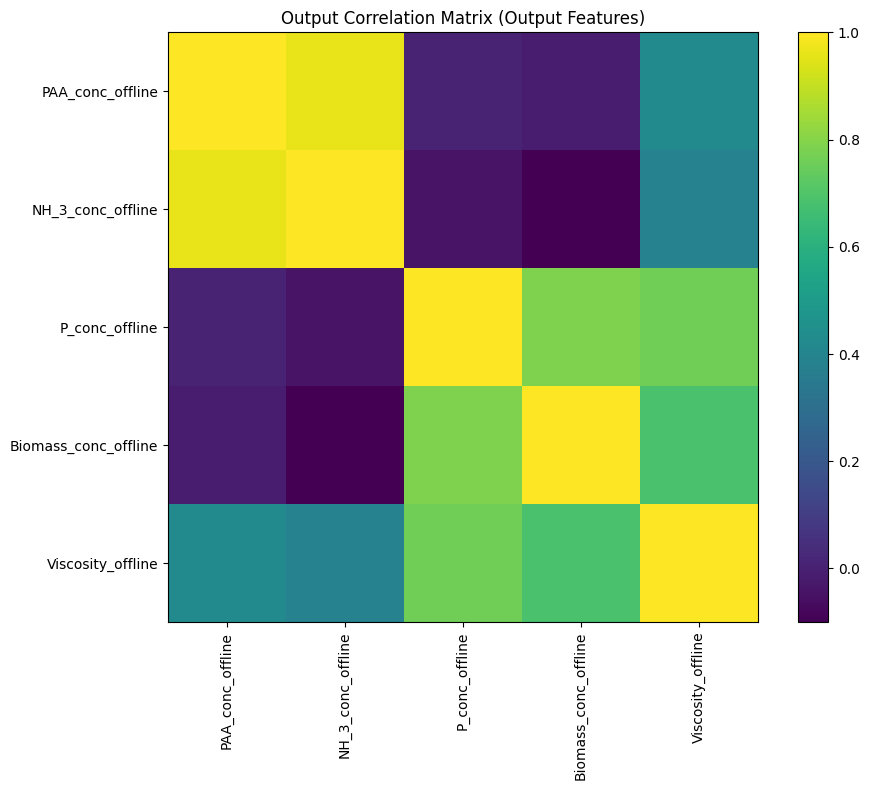

In [111]:
out_corr_matrix = df_clean[output_features].corr()

plt.figure(figsize=(10, 8))
plt.imshow(out_corr_matrix, cmap='viridis')
plt.colorbar()

plt.xticks(ticks=range(len(out_corr_matrix.columns)), 
           labels=out_corr_matrix.columns, 
           rotation=90,
           fontsize=10)

plt.yticks(ticks=range(len(out_corr_matrix.columns)), 
           labels=out_corr_matrix.columns,
           fontsize=10)

plt.title("Output Correlation Matrix (Output Features)")
plt.tight_layout()
plt.show()

In [112]:
import numpy as np

threshold = 0.9
out_upper_triangle = out_corr_matrix.where(
    np.triu(np.ones(out_corr_matrix.shape), k=1).astype(bool)
)

# Find pairs above threshold
out_high_corr_pairs = (
    out_upper_triangle.stack()
    .reset_index()
    .rename(columns={'level_0': 'Feature_1', 
                     'level_1': 'Feature_2', 
                     0: 'Correlation'})
    .query('abs(Correlation) >= @threshold')
    .sort_values('Correlation', ascending=False)
    .reset_index(drop=True)
)

print(f"Highly correlated pairs (|r| >= {threshold}):\n")
print(out_high_corr_pairs.to_string(index=False))

Highly correlated pairs (|r| >= 0.9):

       Feature_1         Feature_2  Correlation
PAA_conc_offline NH_3_conc_offline      0.96372


In [113]:
df_clean.drop(columns=['NH_3_conc_offline'], 
              inplace=True)

output_features = [col for col in output_features if col != 'NH_3_conc_offline']


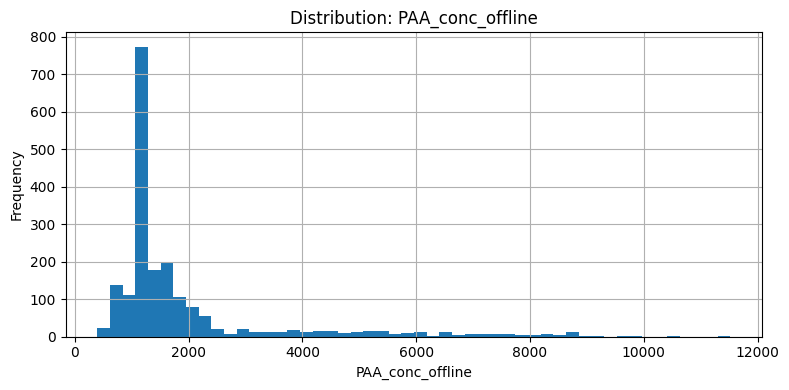

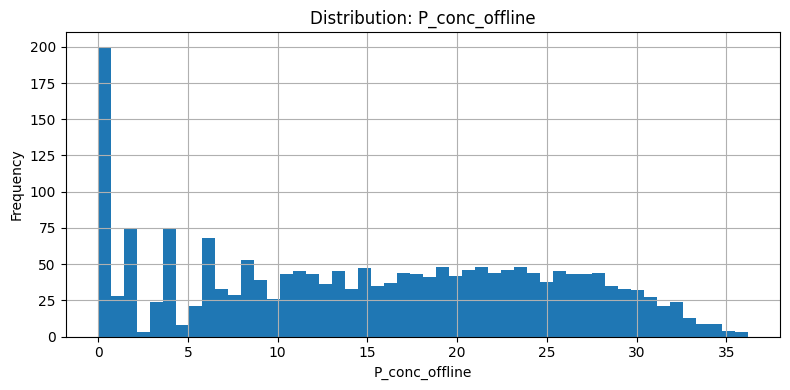

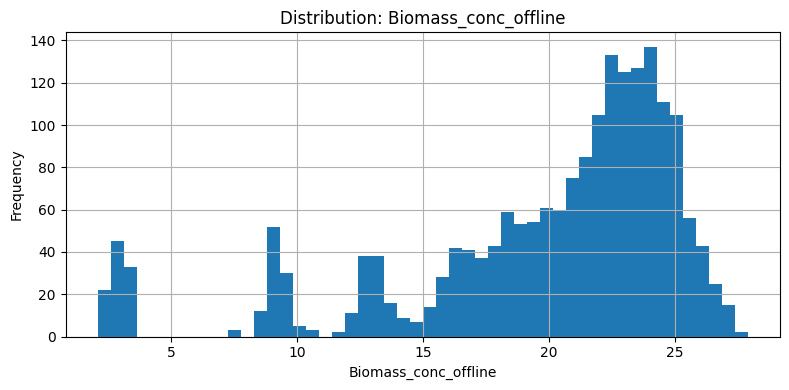

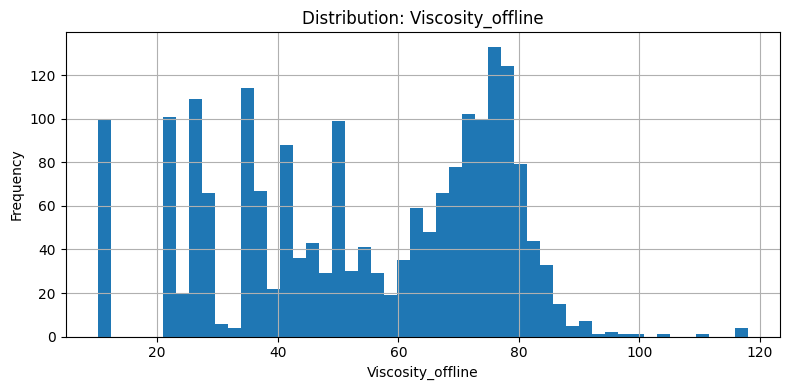

In [114]:
for col in output_features:
    plt.figure(figsize=(8, 4))

    df_clean[col].hist(bins=50)
    plt.title(f"Distribution: {col.split('(')[0]}")
    plt.xlabel(col.split('(')[0])
    plt.ylabel("Frequency")
    
    plt.tight_layout()
    plt.show()

In [115]:
default_backup = df_clean[output_features].copy()

# WEEK 3 To Be Evaluate
# 3) Data Preparation

In [291]:
# Metadata columns — never used as features
meta_cols = ['batch_id', 'control_mode', 'no_raman']

# Target columns
output_features = [
    'P_conc_offline',
    'Biomass_conc_offline',
    'PAA_conc_offline',
    'Viscosity_offline'
]

# Input features — everything else except metadata and targets
input_features = [col for col in df_clean.columns 
                  if col not in meta_cols + output_features +['time'] ]

print(f"Input features  : {len(input_features)}")
print(f"Output features : {len(output_features)}")

Input features  : 27
Output features : 4


In [294]:
import numpy as np

all_batches = df_clean['batch_id'].unique()
print(f"Total batches: {len(all_batches)}")

np.random.seed(42)
shuffled = all_batches.copy()
np.random.shuffle(shuffled)

train_size = int(0.8 * len(shuffled))
val_size   = int(0.1 * len(shuffled))

train_batches = shuffled[:train_size]
val_batches   = shuffled[train_size:train_size + val_size]
test_batches  = shuffled[train_size + val_size:]

df_train = df_clean[df_clean['batch_id'].isin(train_batches)].copy()
df_val   = df_clean[df_clean['batch_id'].isin(val_batches)].copy()
df_test  = df_clean[df_clean['batch_id'].isin(test_batches)].copy()

print(f"Train : {len(train_batches)} batches — {len(df_train)} rows")
print(f"Val   : {len(val_batches)} batches  — {len(df_val)} rows")
print(f"Test  : {len(test_batches)} batches  — {len(df_test)} rows")

Total batches: 100
Train : 80 batches — 90705 rows
Val   : 10 batches  — 11305 rows
Test  : 10 batches  — 10925 rows


In [295]:
df_train.to_csv("train.csv", index=False)
df_val.to_csv("val.csv", index=False)
df_test.to_csv("test.csv", index=False)

Verifying data leakages

In [296]:
# Ensure no batch appears in more than one split
assert len(set(train_batches) & set(val_batches))  == 0, "Train/Val overlap!"
assert len(set(train_batches) & set(test_batches)) == 0, "Train/Test overlap!"
assert len(set(val_batches)   & set(test_batches)) == 0, "Val/Test overlap!"

print("No batch leakage across splits ✓")
print(f"\nFinal summary:")
print(f"  Train : {len(train_batches)} batches")
print(f"  Val   : {len(val_batches)} batches")
print(f"  Test  : {len(test_batches)} batches")
print(f"  X shape per batch : (n_timesteps, {len(input_features)})")
print(f"  y shape per batch : (n_timesteps, {len(output_features)})")

No batch leakage across splits ✓

Final summary:
  Train : 80 batches
  Val   : 10 batches
  Test  : 10 batches
  X shape per batch : (n_timesteps, 27)
  y shape per batch : (n_timesteps, 4)


In [297]:
feature_scaler = StandardScaler()
feature_scaler.fit(df_train[input_features])

df_train[input_features] = feature_scaler.transform(df_train[input_features])
df_val[input_features]   = feature_scaler.transform(df_val[input_features])
df_test[input_features]  = feature_scaler.transform(df_test[input_features])

In [298]:
target_scaler = StandardScaler()
target_scaler.fit(df_train[output_features])

df_train[output_features] = target_scaler.transform(df_train[output_features])
df_val[output_features]   = target_scaler.transform(df_val[output_features])
df_test[output_features]  = target_scaler.transform(df_test[output_features])

In [312]:
def build_sequences(df, input_features, output_features):
    """
    Returns per batch:
        X    : (n_timesteps, n_features + 1)  — includes time (UNSCALED)
        y    : (n_timesteps, n_targets)
        mask : (n_timesteps,)
    """
    X_list, y_list, mask_list, batch_ids = [], [], [], []

    for batch_id in sorted(df['batch_id'].unique()):
        batch = df[df['batch_id'] == batch_id].sort_values('time')

        # ✅ Scaled features
        X_features = batch[input_features].values.astype(np.float32)

        # ✅ Raw time (NOT scaled)
        time_values = batch['time'].values.astype(np.float32).reshape(-1, 1)

        # 🔥 Combine features + time
        X_batch = np.concatenate([X_features, time_values], axis=1)

        y_batch    = batch[output_features].values.astype(np.float32)
        mask_batch = ~np.isnan(y_batch).any(axis=1)

        y_batch = np.nan_to_num(y_batch, nan=0.0)

        X_list.append(X_batch)
        y_list.append(y_batch)
        mask_list.append(mask_batch)
        batch_ids.append(batch_id)

    return X_list, y_list, mask_list, batch_ids

X_train, y_train, mask_train, ids_train = build_sequences(df_train, input_features, output_features)
X_val,   y_val,   mask_val,   ids_val   = build_sequences(df_val,   input_features, output_features)
X_test,  y_test,  mask_test,  ids_test  = build_sequences(df_test,  input_features, output_features)

print(f"\nSample shapes:")
print(f"  X[0] : {X_train[0].shape}")
print(f"  y[0] : {y_train[0].shape}")
print(f"  mask labeled points: {mask_train[0].sum()} per batch")


Sample shapes:
  X[0] : (1120, 28)
  y[0] : (1120, 4)
  mask labeled points: 19 per batch


In [311]:
# def build_sequences(df, input_features, output_features):
#     """
#     Returns per batch:
#         X    : (n_timesteps, n_features)  — all timesteps
#         y    : (n_timesteps, n_targets)   — sparse, NaN where unmeasured
#         mask : (n_timesteps,)             — True where targets available
#     """
#     X_list, y_list, mask_list, batch_ids = [], [], [], []

#     for batch_id in sorted(df['batch_id'].unique()):
#         batch = df[df['batch_id'] == batch_id].sort_values('time')

#         X_batch    = batch[input_features].values.astype(np.float32)
#         y_batch    = batch[output_features].values.astype(np.float32)
#         mask_batch = ~np.isnan(y_batch).any(axis=1)

#         # Replace NaN in y with 0 (masked out during loss anyway)
#         y_batch    = np.nan_to_num(y_batch, nan=0.0)

#         X_list.append(X_batch)
#         y_list.append(y_batch)
#         mask_list.append(mask_batch)
#         batch_ids.append(batch_id)

#     return X_list, y_list, mask_list, batch_ids




# 4) Model Preparation

In [313]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [314]:
class FermentationDataset(Dataset):
    def __init__(self, X_list, y_list, mask_list):
        self.X    = X_list
        self.y    = y_list
        self.mask = mask_list

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.X[idx],    dtype=torch.float32),
            torch.tensor(self.y[idx],    dtype=torch.float32),
            torch.tensor(self.mask[idx], dtype=torch.bool)
        )

In [315]:
train_dataset = FermentationDataset(X_train, y_train, mask_train)
val_dataset   = FermentationDataset(X_val,   y_val,   mask_val)
test_dataset  = FermentationDataset(X_test,  y_test,  mask_test)

# batch_size=1 because each fermentation batch has different length
train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=1, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=1, shuffle=False)

In [316]:
print(f"\nDataLoaders ready:")
print(f"  Train batches : {len(train_loader)}")
print(f"  Val batches   : {len(val_loader)}")
print(f"  Test batches  : {len(test_loader)}")



DataLoaders ready:
  Train batches : 80
  Val batches   : 10
  Test batches  : 10


In [317]:
class FermentationLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, dropout=0.2):
        super(FermentationLSTM, self).__init__()

        self.lstm = nn.LSTM(
            input_size  = input_size,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            batch_first = True,        # input shape: (batch, seq, features)
            dropout     = dropout if num_layers > 1 else 0
        )

        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, output_size)  # predict all 4 targets
        )

    def forward(self, x):
        # x shape: (batch, seq_len, input_size)
        lstm_out, _ = self.lstm(x)
        # lstm_out shape: (batch, seq_len, hidden_size)
        predictions = self.fc(lstm_out)
        # predictions shape: (batch, seq_len, output_size)
        return predictions

In [324]:
model = FermentationLSTM(
    input_size  = len(input_features)+1,
    hidden_size = 128,
    num_layers  = 2,
    output_size = len(output_features),
    dropout     = 0.2
)

In [325]:
print(f"\nModel architecture:")
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")



Model architecture:
FermentationLSTM(
  (lstm): LSTM(28, 128, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=4, bias=True)
  )
)

Total parameters: 221,508


In [326]:
def masked_mse_loss(predictions, targets, mask):
    """
    predictions : (batch, seq_len, n_targets)
    targets     : (batch, seq_len, n_targets)
    mask        : (batch, seq_len) — True where measurement exists
    """
    # Expand mask to cover all targets
    mask_expanded = mask.unsqueeze(-1).expand_as(predictions)

    # Only keep masked values
    pred_masked   = predictions[mask_expanded]
    target_masked = targets[mask_expanded]

    if pred_masked.numel() == 0:
        return torch.tensor(0.0, requires_grad=True)

    return nn.MSELoss()(pred_masked, target_masked)

# 5) Model Training 

In [327]:
device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model     = model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                optimizer, patience=5, factor=0.5)

In [328]:
N_EPOCHS       = 50
best_val_loss  = float('inf')
train_losses   = []
val_losses     = []

In [329]:
print(f"\nTraining on: {device}")
print("="*50)
for epoch in range(N_EPOCHS):

    # ── Training ──────────────────────────────────────
    model.train()
    epoch_train_loss = 0

    for X_batch, y_batch, mask_batch in train_loader:
        
        X_batch    = X_batch.to(device)
        y_batch    = y_batch.to(device)
        mask_batch = mask_batch.to(device)

        # 1. Forward pass
        predictions = model(X_batch)

        # 2. Compute masked loss
        loss = masked_mse_loss(predictions, y_batch, mask_batch)

        # 3. Zero gradients
        optimizer.zero_grad()

        # 4. Backward pass — compute gradients
        loss.backward()

        # 5. Gradient clipping — prevents exploding gradients in LSTM
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        # 6. Update weights
        optimizer.step()

        epoch_train_loss += loss.item()

    avg_train_loss = epoch_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # ── Validation ────────────────────────────────────
    model.eval()
    epoch_val_loss = 0

    with torch.no_grad():
        for X_batch, y_batch, mask_batch in val_loader:
            X_batch    = X_batch.to(device)
            y_batch    = y_batch.to(device)
            mask_batch = mask_batch.to(device)

            predictions    = model(X_batch)
            loss           = masked_mse_loss(predictions, y_batch, mask_batch)
            epoch_val_loss += loss.item()

    avg_val_loss = epoch_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    scheduler.step(avg_val_loss)

    # Save best model
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), 'best_model.pt')

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:3d}/{N_EPOCHS} | "
              f"Train Loss: {avg_train_loss:.4f} | "
              f"Val Loss: {avg_val_loss:.4f} | "
              f"Best Val: {best_val_loss:.4f}")



Training on: cuda
Epoch   5/50 | Train Loss: 0.1598 | Val Loss: 0.0709 | Best Val: 0.0688
Epoch  10/50 | Train Loss: 0.0937 | Val Loss: 0.0673 | Best Val: 0.0542
Epoch  15/50 | Train Loss: 0.0836 | Val Loss: 0.0423 | Best Val: 0.0394
Epoch  20/50 | Train Loss: 0.0637 | Val Loss: 0.0220 | Best Val: 0.0220
Epoch  25/50 | Train Loss: 0.0552 | Val Loss: 0.0195 | Best Val: 0.0189
Epoch  30/50 | Train Loss: 0.0530 | Val Loss: 0.0219 | Best Val: 0.0184
Epoch  35/50 | Train Loss: 0.0444 | Val Loss: 0.0240 | Best Val: 0.0177
Epoch  40/50 | Train Loss: 0.0408 | Val Loss: 0.0159 | Best Val: 0.0132
Epoch  45/50 | Train Loss: 0.0386 | Val Loss: 0.0149 | Best Val: 0.0132
Epoch  50/50 | Train Loss: 0.0335 | Val Loss: 0.0152 | Best Val: 0.0132


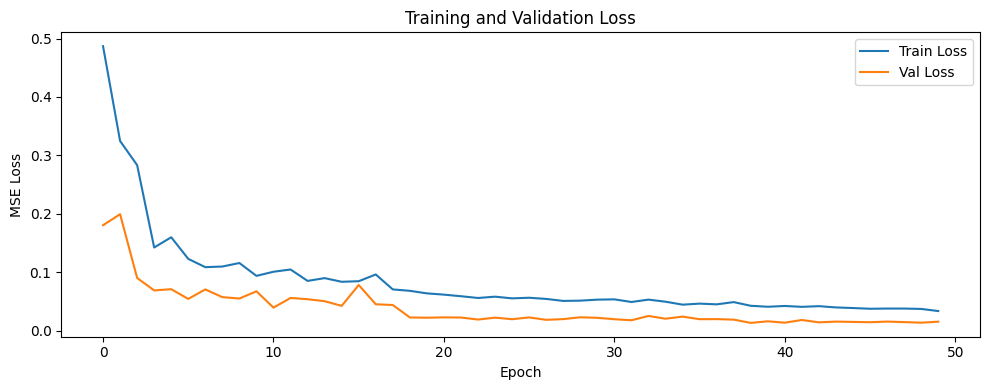

In [330]:
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses,   label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.tight_layout()
plt.show()

# 6) Model Evaluation

In [334]:
model.load_state_dict(torch.load('best_model.pt'))
model.eval()

all_preds, all_targets = [], []

with torch.no_grad():
    for X_batch, y_batch, mask_batch in test_loader:
        X_batch    = X_batch.to(device)
        y_batch    = y_batch.to(device)
        mask_batch = mask_batch.to(device)

        predictions = model(X_batch)

        # Expand mask
        mask_exp = mask_batch.unsqueeze(-1).expand_as(predictions)

        # Collect masked values
        preds_masked   = predictions[mask_exp].cpu().numpy()
        targets_masked = y_batch[mask_exp].cpu().numpy()

        all_preds.append(preds_masked)
        all_targets.append(targets_masked)

# Concatenate
all_preds   = np.concatenate(all_preds).reshape(-1, len(output_features))
all_targets = np.concatenate(all_targets).reshape(-1, len(output_features))

# Convert back to real-world values
all_preds_real   = target_scaler.inverse_transform(all_preds)
all_targets_real = target_scaler.inverse_transform(all_targets)

from sklearn.metrics import mean_squared_error, r2_score

print("\nTest Set Performance:")
print("="*50)

for i, col in enumerate(output_features):
    rmse = np.sqrt(mean_squared_error(all_targets_real[:, i],
                                      all_preds_real[:, i]))
    r2   = r2_score(all_targets_real[:, i],
                    all_preds_real[:, i])

    print(f"{col:30} RMSE: {rmse:.4f}  R²: {r2:.4f}")


Test Set Performance:
P_conc_offline                 RMSE: 1.0519  R²: 0.9885
Biomass_conc_offline           RMSE: 0.9313  R²: 0.9733
PAA_conc_offline               RMSE: 164.5357  R²: 0.9563
Viscosity_offline              RMSE: 2.5011  R²: 0.9852


# 7) Visualization

In [335]:
ylabel_map = {
    'P_conc_offline': 'P (g L⁻¹)',
    'Biomass_conc_offline': 'X (g L⁻¹)',
    'PAA_conc_offline': 'PAA (g L⁻¹)',
    'Viscosity_offline': 'Viscosity (cP)'
}

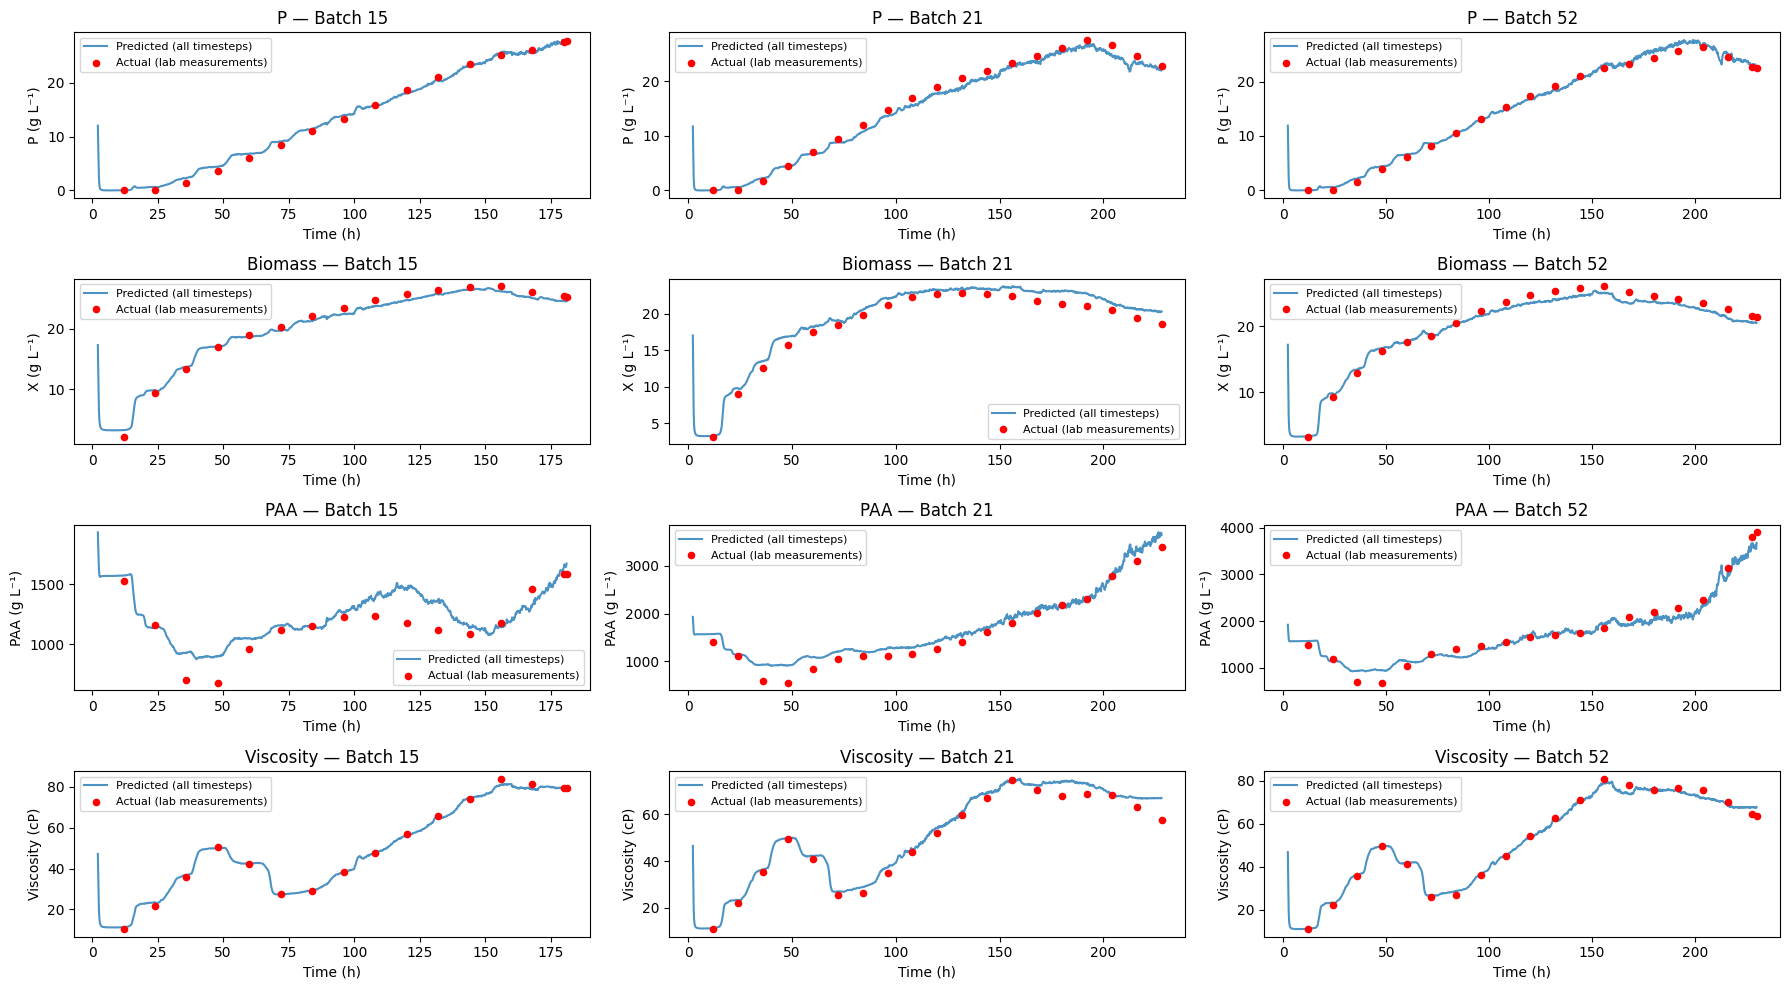

Leakage sanity checks:
Train batches in test: 0
Val batches in test  : 0
Test batch count     : 10


In [337]:
# ============================================================
# CHECK 1 — Plot predicted vs actual for test batches (REAL UNITS)
# ============================================================
model.eval()

fig, axes = plt.subplots(len(output_features), 3, figsize=(18,10))
test_batch_ids = list(ids_test)[:3]  # first 3 test batches

for col_idx, col in enumerate(output_features):
    for plot_idx, batch_id in enumerate(test_batch_ids):

        batch_idx = ids_test.index(batch_id)

        X_b = torch.tensor(X_test[batch_idx], dtype=torch.float32).unsqueeze(0).to(device)
        mask_b = mask_test[batch_idx]

        with torch.no_grad():
            pred_scaled = model(X_b).squeeze(0).cpu().numpy()  # (seq_len, n_targets)

        # 🔥 Inverse transform predictions (ALL timesteps)
        pred_real = target_scaler.inverse_transform(pred_scaled)

        # Get time axis
        batch_df = df_test[df_test['batch_id'] == batch_id].sort_values('time')
        time_all  = batch_df['time'].values
        time_meas = time_all[mask_b]

        # Predictions (real units)
        pred_all = pred_real[:, col_idx]

        # 🔥 True values (inverse transform ONLY measured points)
        true_scaled = y_test[batch_idx][mask_b]  # (n_points, n_targets)
        true_real   = target_scaler.inverse_transform(true_scaled)

        true_meas = true_real[:, col_idx]

        ax = axes[col_idx, plot_idx]

        ax.plot(time_all, pred_all, label='Predicted (all timesteps)', alpha=0.8)
        ax.scatter(time_meas, true_meas,
                   label='Actual (lab measurements)',
                   color='red', zorder=5, s=20)

        ax.set_title(f"{col.split('_')[0]} — Batch {batch_id}")
        ax.set_xlabel("Time (h)")
        ax.set_ylabel(ylabel_map.get(col, col))
        ax.legend(fontsize=8)

plt.tight_layout()
plt.show()
# ============================================================
# CHECK 2 — Are results too good? Check for leakage
# ============================================================
print("Leakage sanity checks:")
print(f"Train batches in test: {len(set(train_batches) & set(ids_test))}")
print(f"Val batches in test  : {len(set(val_batches) & set(ids_test))}")
print(f"Test batch count     : {len(ids_test)}")